<a href="https://colab.research.google.com/github/jimenz2/Metodogv2/blob/main/Copia_de_V2ed93.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Base de datos cargada: 34 registros.
Generaciones documentadas: 25 a 1
Rango temporal: 1234 — 1992

CSV exportado: ZAJH_datos_linaje_femenino_georef_completo_20260428.csv
Mapa 1 guardado: ZAJH_grafico_mapa_distribucion_geografica_completo_20260428.png


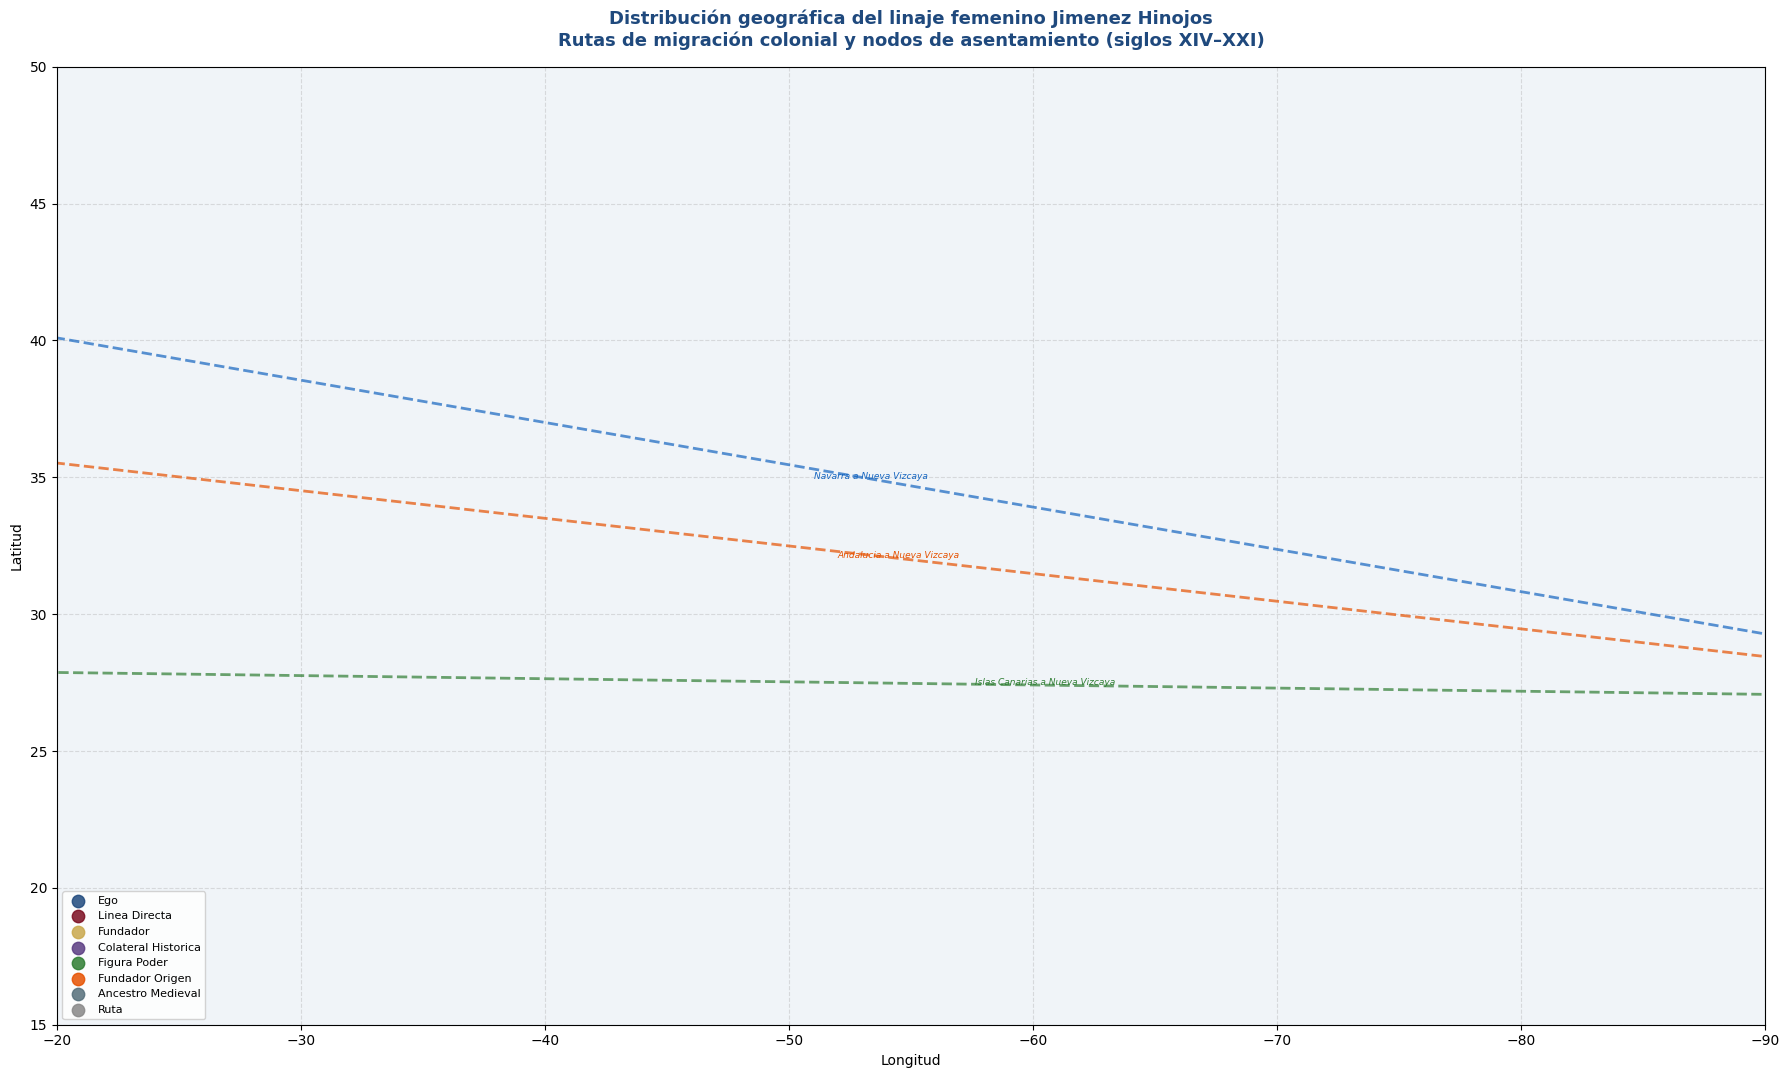

Mapa 2 guardado: ZAJH_grafico_mapa_zoom_chihuahua_20260428.png


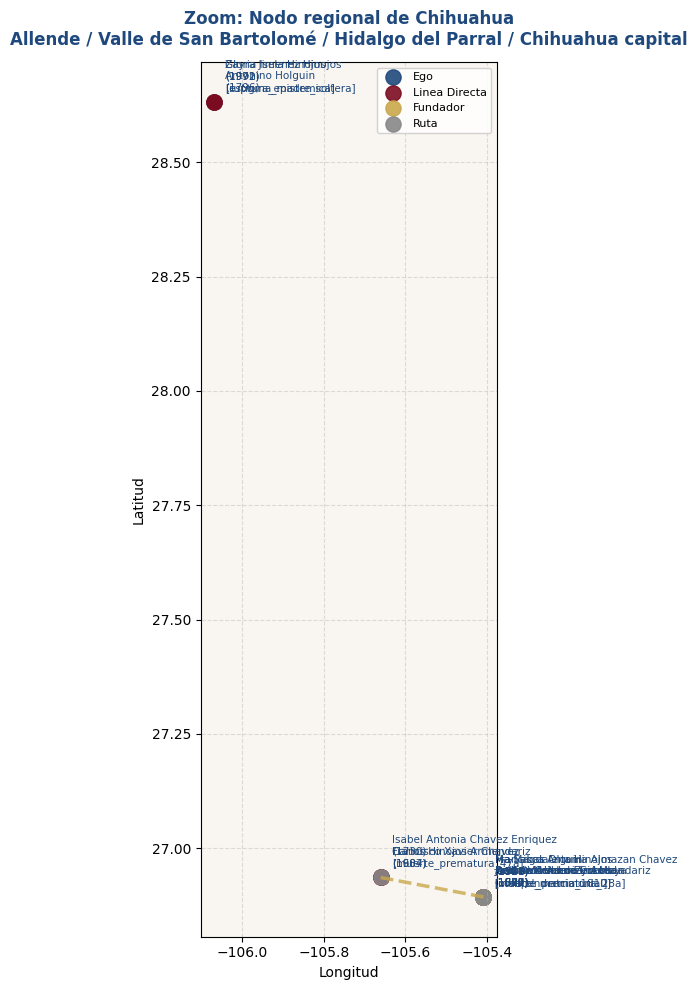

Mapa 3 guardado: ZAJH_grafico_linea_tiempo_patron_control_20260428.png


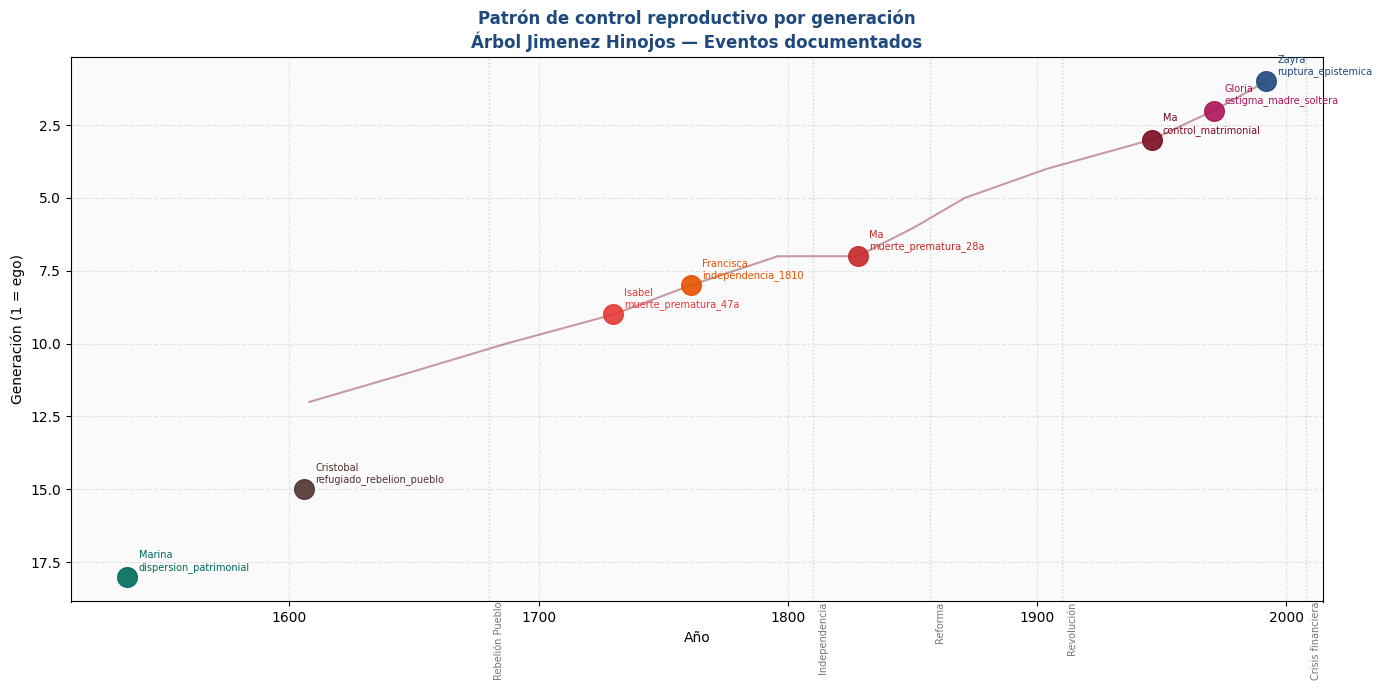

Grafo guardado: ZAJH_grafico_grafo_rutas_historicas_20260428.png


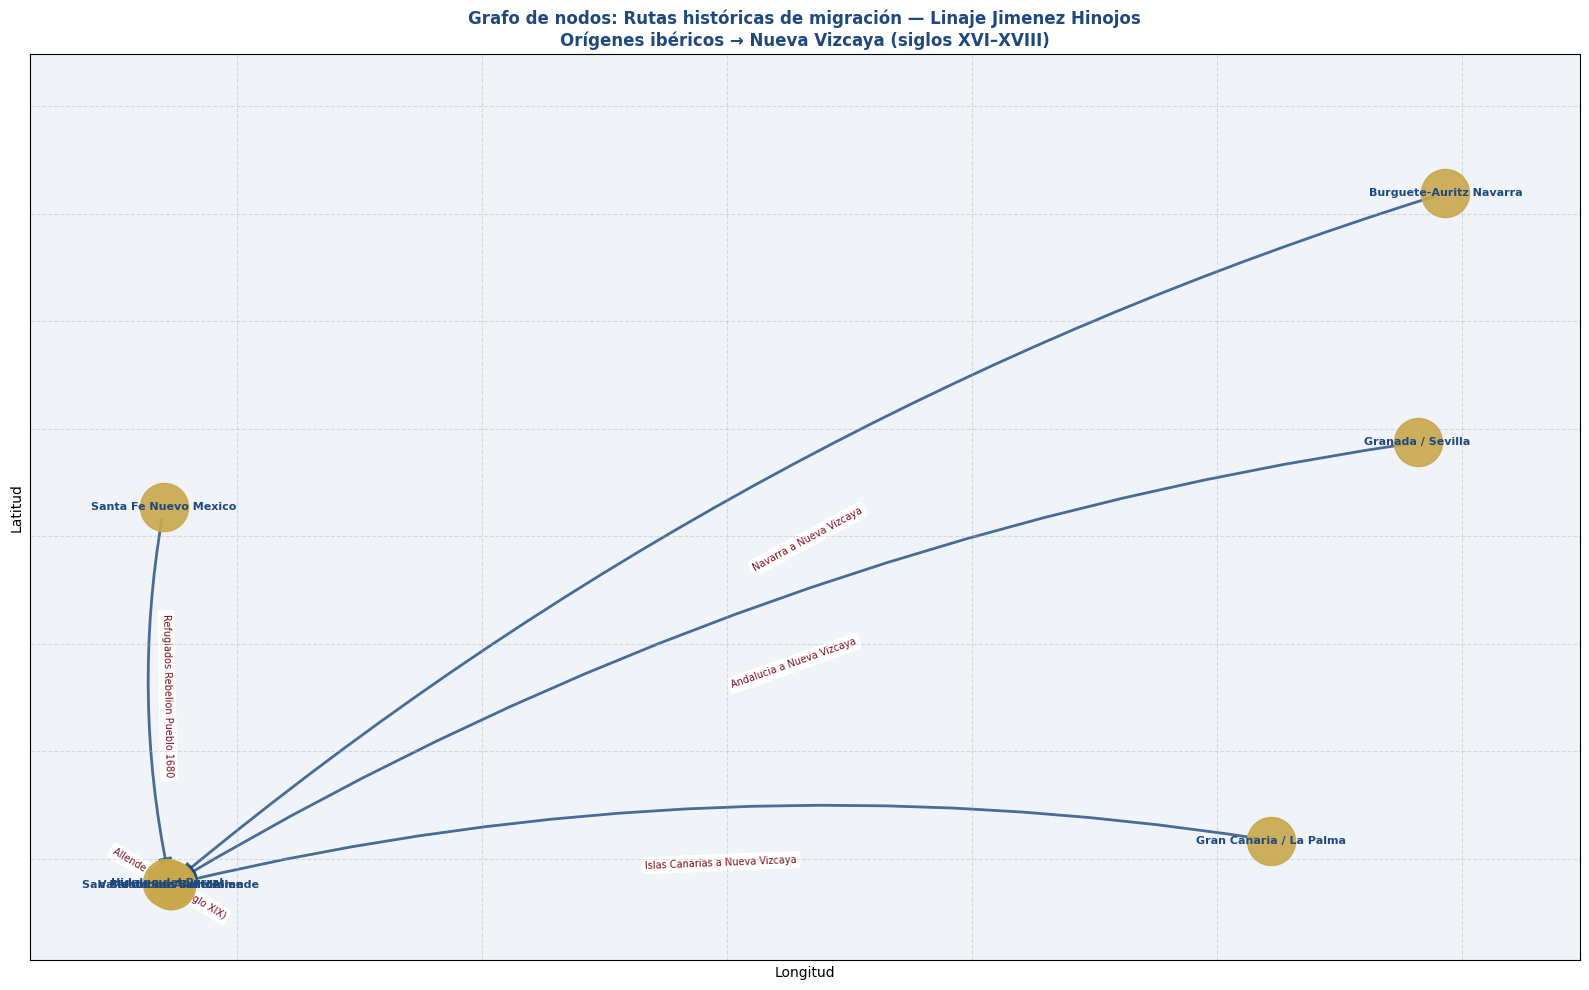

Mapa interactivo guardado: ZAJH_mapa_linaje_interactivo_folium_20260428.html

ESTADÍSTICAS DEL CORPUS — ÁRBOL JIMENEZ HINOJOS
Total de registros:          34
Personas con patrón control: 8
Rutas documentadas:          5
Países de origen:            3
Rango temporal:              1234 — 1992
Nivel de confianza 'alta':   32
Nivel de confianza 'media':  1
Nivel de confianza 'baja':   0

Distribución por relación:
relacion
linea_directa          12
ruta                   10
fundador                4
fundador_origen         3
colateral_historica     2
ego                     1
figura_poder            1
ancestro_medieval       1

Patrones de control documentados:
patron_control
ruptura_epistemica           1
estigma_madre_soltera        1
control_matrimonial          1
muerte_prematura_28a         1
independencia_1810           1
muerte_prematura_47a         1
dispersion_patrimonial       1
refugiado_rebelion_pueblo    1

ARCHIVOS GENERADOS
  ✓ ZAJH_datos_linaje_femenino_georef_completo_2026

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
import networkx as nx
import folium
from shapely.geometry import Point, LineString
from datetime import datetime
import os
import warnings
warnings.filterwarnings("ignore")

def generar_nomenclatura_zenodo(tipo_dato, descripcion, extension):
    fecha = datetime.now().strftime("%Y%m%d")
    nombre = f"ZAJH_{tipo_dato}_{descripcion}_{fecha}.{extension}"
    return nombre

columnas = [
    "id", "nombre_completo", "anio", "periodo_inicio", "periodo_fin",
    "evento", "lugar_historico", "lugar_actual", "pais",
    "latitud", "longitud", "generacion", "relacion",
    "apellido_materno", "fuente", "tipo_dato", "confianza",
    "patron_control", "tipo_ruptura", "tipo_ruta", "ruta_descripcion", "ruta_id"
]

datos = [
    [1,  "Zayra Jimenez Hinojos",          1992, 1992, 2026,
     "residencia", "Chihuahua", "Chihuahua", "Mexico",
     28.6320, -106.0691, 1, "ego", "Jimenez",
     "propio", "exacto", "alta",
     "ruptura_epistemica", "formalizacion_academica", None, None, None],

    [2,  "Gloria Isela Hinojos",            1971, 1971, 2026,
     "residencia", "Chihuahua", "Chihuahua", "Mexico",
     28.6320, -106.0691, 2, "linea_directa", "Hinojos",
     "registro_civil", "exacto", "alta",
     "estigma_madre_soltera", "divorcio_interferido", None, None, None],

    [3,  "Ma Magdalena Hinojos",            1946, 1946, 2026,
     "residencia", "Allende Chihuahua", "Allende", "Mexico",
     26.8937, -105.4087, 3, "linea_directa", "Hinojos",
     "registro_civil", "exacto", "alta",
     "control_matrimonial", "separacion_materna", None, None, None],

    [4,  "Carlos Hinojos Armendariz",       1904, 1904, 1960,
     "residencia", "Hidalgo del Parral", "Parral", "Mexico",
     26.9363, -105.6609, 4, "linea_directa", "Hinojos",
     "registro_civil", "exacto", "alta",
     None, None, None, None, None],

    [5,  "Delfina Armendariz Moya",         1871, 1871, 1962,
     "residencia", "Valle de Allende", "Allende", "Mexico",
     26.8937, -105.4087, 5, "linea_directa", "Armendariz",
     "registro_civil", "exacto", "alta",
     None, None, None, None, None],

    [6,  "Juan Armendariz",                 1851, 1851, 1924,
     "residencia", "Valle de Allende", "Allende", "Mexico",
     26.8937, -105.4087, 6, "linea_directa", "Armendariz",
     "registro_civil", "exacto", "alta",
     None, None, None, None, None],

    [7,  "Ma Sabas Olguin",                 1828, 1828, 1856,
     "residencia", "Valle de Allende", "Allende", "Mexico",
     26.8937, -105.4087, 7, "linea_directa", "Olguin",
     "registro_historico", "exacto", "alta",
     "muerte_prematura_28a", "quiebre_generacional", None, None, None],

    [8,  "Antonino Holguin",                1796, 1796, 1860,
     "residencia", "Chihuahua", "Chihuahua", "Mexico",
     28.6320, -106.0691, 7, "linea_directa", "Holguin",
     "registro_historico", "exacto", "alta",
     None, None, None, None, None],

    [9,  "Francisca Antonia Almazan Chavez",1761, 1761, 1831,
     "residencia", "Valle de Allende", "Allende", "Mexico",
     26.8937, -105.4087, 8, "linea_directa", "Almazan",
     "registro_parroquial", "exacto", "alta",
     "independencia_1810", "quiebre_colonial", None, None, None],

    [10, "Isabel Antonia Chavez Enriquez",  1730, 1730, 1777,
     "residencia", "Hidalgo del Parral", "Parral", "Mexico",
     26.9363, -105.6609, 9, "linea_directa", "Chavez",
     "registro_parroquial", "exacto", "alta",
     "muerte_prematura_47a", "quiebre_generacional", None, None, None],

    [11, "Francisco Xavier Chavez",         1687, 1687, 1764,
     "residencia", "Hidalgo del Parral", "Parral", "Mexico",
     26.9363, -105.6609, 10, "linea_directa", "Chavez",
     "registro_parroquial", "exacto", "alta",
     None, None, None, None, None],

    [12, "Catalina Varela de Lozada",       1648, 1648, 1710,
     "residencia", "Nueva Espana", "Ciudad de Mexico", "Mexico",
     19.4326, -99.1332, 11, "linea_directa", "Varela",
     "archivo_general", "exacto", "alta",
     None, None, None, None, None],

    [13, "Pedro Varela de Losada",          1608, 1608, 1667,
     "residencia", "Valle de San Bartolome", "Allende", "Mexico",
     26.8937, -105.4087, 12, "linea_directa", "Varela",
     "archivo_general", "exacto", "alta",
     None, None, None, None, None],

    [14, "Beatriz de Estrada",              1520, 1515, 1580,
     "residencia", "Nueva Espana", "Ciudad de Mexico", "Mexico",
     19.4326, -99.1332, 18, "colateral_historica", "Estrada",
     "viudez_sin_titulo_propiedad", "capital_sin_institucionalizacion",
     None, None, None],

    [15, "Marina Vasquez de Coronado",      1535, 1530, 1590,
     "residencia", "Nueva Espana", "Ciudad de Mexico", "Mexico",
     19.4326, -99.1332, 18, "colateral_historica", "Vasquez",
     "archivo_general_indias", "exacto", "alta",
     "dispersion_patrimonial", "hija_explorador_ausente",
     None, None, None],

    [16, "Bernardo Azcue y Armendariz",     1640, 1635, 1697,
     "asentamiento", "San Bartolome Valle Allende", "Allende", "Mexico",
     26.8937, -105.4087, 13, "fundador", "Azcue",
     "registro_parroquial", "exacto", "alta",
     None, None, None, None, None],

    [17, "Juan del Hierro Zereceda",        1627, 1620, 1668,
     "asentamiento", "San Bartolome Valle Allende", "Allende", "Mexico",
     26.8937, -105.4087, 13, "fundador", "Hierro",
     "registro_parroquial", "exacto", "alta",
     None, None, None, None, None],

    [18, "Andres Cordero Cobos",            1572, 1565, 1642,
     "asentamiento", "Valle de San Bartolome", "Allende", "Mexico",
     26.8937, -105.4087, 13, "fundador", "Cordero",
     "archivo_general_indias", "exacto", "alta",
     None, None, None, None, None],

    [19, "Cristobal Enriquez",              1606, 1600, 1643,
     "residencia", "Santa Fe Nuevo Mexico", "Santa Fe NM", "USA",
     35.6870, -105.9378, 15, "fundador", "Enriquez",
     "registro_historico", "exacto", "alta",
     "refugiado_rebelion_pueblo", None, None, None, None],

    [20, "Sebastian Garcia de Aguiar",      1619, 1615, 1684,
     "origen", "La Palma Islas Canarias", "La Palma", "Espana",
     28.6835, -17.7642, 16, "fundador_origen", "Garcia",
     "archivo_general_indias", "exacto", "alta",
     None, None, None, None, None],

    [21, "Martin Monzon",                   1557, 1550, 1620,
     "origen", "Gran Canaria", "Gran Canaria", "Espana",
     27.9202, -15.5474, 15, "fundador_origen", "Monzon",
     "archivo_general_indias", "exacto", "alta",
     None, None, None, None, None],

    [22, "Andres Cordero",                  1519, 1510, 1652,
     "origen", "Granada Andalucia", "Granada", "Espana",
     37.1773, -3.5986, 14, "fundador_origen", "Cordero",
     "archivo_general_indias", "inferido", "alta",
     None, None, None, None, None],

    [23, "Gobernador Alonso de Estrada",    1480, 1475, 1531,
     "residencia", "Nueva Espana", "Ciudad de Mexico", "Mexico",
     19.4326, -99.1332, 17, "figura_poder", "Estrada",
     "archivo_general_indias", "exacto", "alta",
     None, None, None, None, None],

    [24, "Infante Manuel de Castilla",      1234, 1234, 1283,
     "residencia", "Castilla", "Burgos", "Espana",
     42.3440, -3.6970, 25, "ancestro_medieval", "Castilla",
     "fuente_medieval", "exacto", "media",
     None, None, None, None, None],

    [25, "Ruta_Andalucia_Origen",           1580, 1570, 1600,
     "inicio_ruta", "Granada / Sevilla", "Andalucia", "Espana",
     37.1773, -3.5986, None, "ruta", "desconocido",
     "archivo_general_indias", "inferido", "alta",
     None, None, "migracion_colonial", "Andalucia a Nueva Vizcaya", "ruta_001"],

    [26, "Ruta_Andalucia_Destino",          1610, 1600, 1630,
     "fin_ruta", "Valle de San Bartolome", "Allende", "Mexico",
     26.8937, -105.4087, None, "ruta", "desconocido",
     "registro_parroquial", "inferido", "alta",
     None, None, "migracion_colonial", "Andalucia a Nueva Vizcaya", "ruta_001"],

    [27, "Ruta_Navarra_Origen",             1635, 1625, 1645,
     "inicio_ruta", "Burguete-Auritz Navarra", "Navarra", "Espana",
     42.9800, -1.3167, None, "ruta", "desconocido",
     "archivo_general_indias", "inferido", "alta",
     None, None, "migracion_colonial", "Navarra a Nueva Vizcaya", "ruta_002"],

    [28, "Ruta_Navarra_Destino",            1665, 1655, 1675,
     "fin_ruta", "San Bartolome Valle Allende", "Allende", "Mexico",
     26.8937, -105.4087, None, "ruta", "desconocido",
     "registro_parroquial", "inferido", "alta",
     None, None, "migracion_colonial", "Navarra a Nueva Vizcaya", "ruta_002"],

    [29, "Ruta_Canarias_Origen",            1610, 1600, 1625,
     "inicio_ruta", "Gran Canaria / La Palma", "Islas Canarias", "Espana",
     27.9202, -15.5474, None, "ruta", "desconocido",
     "archivo_general_indias", "inferido", "alta",
     None, None, "migracion_colonial", "Islas Canarias a Nueva Vizcaya", "ruta_003"],

    [30, "Ruta_Canarias_Destino",           1645, 1635, 1660,
     "fin_ruta", "Valle de San Bartolome", "Allende", "Mexico",
     26.8937, -105.4087, None, "ruta", "desconocido",
     "registro_parroquial", "inferido", "alta",
     None, None, "migracion_colonial", "Islas Canarias a Nueva Vizcaya", "ruta_003"],

    [31, "Ruta_NuevoMexico_Origen",         1680, 1678, 1682,
     "inicio_ruta", "Santa Fe Nuevo Mexico", "Santa Fe NM", "USA",
     35.6870, -105.9378, None, "ruta", "desconocido",
     "registro_historico", "exacto", "alta",
     None, None, "migracion_forzada", "Refugiados Rebelion Pueblo 1680", "ruta_004"],

    [32, "Ruta_NuevoMexico_Destino",        1685, 1683, 1690,
     "fin_ruta", "Valle de San Bartolome", "Allende", "Mexico",
     26.8937, -105.4087, None, "ruta", "desconocido",
     "registro_parroquial", "exacto", "alta",
     None, None, "migracion_forzada", "Refugiados Rebelion Pueblo 1680", "ruta_004"],

    [33, "Ruta_Allende_Parral_Origen",      1871, 1860, 1880,
     "inicio_ruta", "Valle de Allende", "Allende", "Mexico",
     26.8937, -105.4087, None, "ruta", "desconocido",
     "registro_civil", "exacto", "alta",
     None, None, "migracion_interna", "Allende a Parral (siglo XIX)", "ruta_005"],

    [34, "Ruta_Allende_Parral_Destino",     1900, 1895, 1910,
     "fin_ruta", "Hidalgo del Parral", "Parral", "Mexico",
     26.9363, -105.6609, None, "ruta", "desconocido",
     "registro_civil", "exacto", "alta",
     None, None, "migracion_interna", "Allende a Parral (siglo XIX)", "ruta_005"],
]

df = pd.DataFrame(datos, columns=columnas)
print(f"Base de datos cargada: {len(df)} registros.")
print(f"Generaciones documentadas: {df['generacion'].dropna().astype(int).max()} a 1")
print(f"Rango temporal: {df['anio'].min()} — {df['anio'].max()}")

csv_nombre = generar_nomenclatura_zenodo("datos", "linaje_femenino_georef_completo", "csv")
df.to_csv(csv_nombre, index=False, encoding="utf-8")
print(f"\nCSV exportado: {csv_nombre}")

geometry = [Point(xy) for xy in zip(df["longitud"], df["latitud"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

gdf_linea   = gdf[gdf["relacion"] == "linea_directa"].copy()
gdf_ego     = gdf[gdf["relacion"] == "ego"].copy()
gdf_rutas   = gdf[gdf["tipo_ruta"].notna()].copy()
gdf_fundad  = gdf[gdf["relacion"] == "fundador"].copy()
gdf_hist    = gdf[gdf["relacion"] == "colateral_historica"].copy()

fig, ax = plt.subplots(1, 1, figsize=(18, 12))
ax.set_facecolor("#f0f4f8")

colores_relacion = {
    "ego":               "#1F497D",
    "linea_directa":     "#7B0C20",
    "fundador":          "#C9A84C",
    "colateral_historica":"#5A3C82",
    "figura_poder":      "#2E7D32",
    "fundador_origen":   "#E65100",
    "ancestro_medieval": "#546E7A",
    "ruta":              "#888888"
}

for rel, color in colores_relacion.items():
    subset = gdf[gdf["relacion"] == rel]
    if not subset.empty:
        subset.plot(ax=ax, marker="o", color=color, markersize=80,
                    alpha=0.85, label=rel.replace("_", " ").title())

rutas_ids = gdf_rutas["ruta_id"].dropna().unique()
colores_ruta = ["#E65100", "#1565C0", "#2E7D32", "#7B0C20", "#C9A84C"]
for i, ruta_id in enumerate(rutas_ids):
    pts = gdf_rutas[gdf_rutas["ruta_id"] == ruta_id].sort_values("anio")
    if len(pts) >= 2:
        linea = LineString(pts.geometry.tolist())
        gpd.GeoSeries([linea], crs="EPSG:4326").plot(
            ax=ax, color=colores_ruta[i % len(colores_ruta)],
            linewidth=2, linestyle="--", alpha=0.7
        )
        desc = pts["ruta_descripcion"].iloc[0]
        mid = linea.interpolate(0.5, normalized=True)
        ax.annotate(desc, xy=(mid.x, mid.y),
                    fontsize=6.5, color=colores_ruta[i % len(colores_ruta)],
                    ha="center", style="italic")

for _, fila in gdf_linea.iterrows():
    ax.annotate(
        f"{fila['nombre_completo']}\n({fila['anio']})",
        xy=(fila.geometry.x, fila.geometry.y),
        xytext=(6, 6), textcoords="offset points",
        fontsize=7, color="#7B0C20", fontweight="bold"
    )

for _, fila in gdf_ego.iterrows():
    ax.annotate(
        f"★ {fila['nombre_completo']}\n({fila['anio']})",
        xy=(fila.geometry.x, fila.geometry.y),
        xytext=(6, -12), textcoords="offset points",
        fontsize=8, color="#1F497D", fontweight="bold"
    )

ax.set_title(
    "Distribución geográfica del linaje femenino Jimenez Hinojos\n"
    "Rutas de migración colonial y nodos de asentamiento (siglos XIV–XXI)",
    fontsize=13, fontweight="bold", color="#1F497D", pad=15
)
ax.set_xlabel("Longitud", fontsize=10)
ax.set_ylabel("Latitud", fontsize=10)
ax.legend(loc="lower left", fontsize=8, framealpha=0.85)
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlim(-20, -90)
ax.set_ylim(15, 50)

plt.tight_layout()
nombre_mapa1 = generar_nomenclatura_zenodo("grafico", "mapa_distribucion_geografica_completo", "png")
plt.savefig(nombre_mapa1, dpi=200, bbox_inches="tight")
print(f"Mapa 1 guardado: {nombre_mapa1}")
plt.show()

gdf_chi = gdf[
    (gdf["longitud"] > -108) & (gdf["longitud"] < -104) &
    (gdf["latitud"] > 25) & (gdf["latitud"] < 30)
].copy()

fig2, ax2 = plt.subplots(1, 1, figsize=(12, 10))
ax2.set_facecolor("#f9f5f0")

for rel, color in colores_relacion.items():
    sub = gdf_chi[gdf_chi["relacion"] == rel]
    if not sub.empty:
        sub.plot(ax=ax2, marker="o", color=color,
                 markersize=120, alpha=0.9, label=rel.replace("_", " ").title())

for i, ruta_id in enumerate(rutas_ids):
    pts = gdf_chi[gdf_chi["ruta_id"] == ruta_id].sort_values("anio")
    if len(pts) >= 2:
        linea = LineString(pts.geometry.tolist())
        gpd.GeoSeries([linea], crs="EPSG:4326").plot(
            ax=ax2, color=colores_ruta[i % len(colores_ruta)],
            linewidth=2.5, linestyle="--", alpha=0.8
        )

for _, fila in gdf_chi.iterrows():
    if fila["relacion"] in ["linea_directa", "ego", "fundador"]:
        etiq = f"{fila['nombre_completo']}\n({fila['anio']})"
        if fila.get("patron_control"):
            etiq += f"\n[{fila['patron_control']}]"
        ax2.annotate(
            etiq,
            xy=(fila.geometry.x, fila.geometry.y),
            xytext=(8, 8), textcoords="offset points",
            fontsize=7.5, color="#1F497D"
        )

ax2.set_title(
    "Zoom: Nodo regional de Chihuahua\n"
    "Allende / Valle de San Bartolomé / Hidalgo del Parral / Chihuahua capital",
    fontsize=12, fontweight="bold", color="#1F497D", pad=12
)
ax2.set_xlabel("Longitud")
ax2.set_ylabel("Latitud")
ax2.legend(loc="upper right", fontsize=8, framealpha=0.85)
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
nombre_mapa2 = generar_nomenclatura_zenodo("grafico", "mapa_zoom_chihuahua", "png")
plt.savefig(nombre_mapa2, dpi=200, bbox_inches="tight")
print(f"Mapa 2 guardado: {nombre_mapa2}")
plt.show()

df_patron = df[df["patron_control"].notna()].copy().sort_values("anio")

fig3, ax3 = plt.subplots(figsize=(14, 7))
ax3.set_facecolor("#fafafa")

colores_patron = {
    "muerte_prematura_28a":          "#C62828",
    "muerte_prematura_47a":          "#E53935",
    "control_matrimonial":           "#7B0C20",
    "estigma_madre_soltera":         "#AD1457",
    "divorcio_interferido":          "#6A1B9A",
    "separacion_materna":            "#4527A0",
    "viudez_sin_titulo_propiedad":   "#1565C0",
    "dispersion_patrimonial":        "#00695C",
    "hija_explorador_ausente":       "#2E7D32",
    "independencia_1810":            "#E65100",
    "quiebre_colonial":              "#BF360C",
    "quiebre_generacional":          "#880E4F",
    "ruptura_epistemica":            "#1F497D",
    "refugiado_rebelion_pueblo":     "#4E342E",
    "formalizacion_academica":       "#1A237E"
}

for _, fila in df_patron.iterrows():
    color = colores_patron.get(fila["patron_control"], "#888888")
    gen = fila["generacion"] if pd.notna(fila["generacion"]) else 0
    ax3.scatter(fila["anio"], gen, s=200, color=color, zorder=5, alpha=0.9)
    ax3.annotate(
        f"{fila['nombre_completo'].split()[0]}\n{fila['patron_control']}",
        xy=(fila["anio"], gen),
        xytext=(8, 5), textcoords="offset points",
        fontsize=7, color=color
    )

gdf_linea_ord = gdf_linea.sort_values("generacion", ascending=False)
anios_gen = df[df["relacion"].isin(["linea_directa", "ego"])].sort_values("generacion", ascending=False)
ax3.plot(anios_gen["anio"], anios_gen["generacion"],
         color="#7B0C20", linewidth=1.5, linestyle="-", alpha=0.4, zorder=2)

quiebres = {
    1680: "Rebelión Pueblo",
    1810: "Independencia",
    1857: "Reforma",
    1910: "Revolución",
    2008: "Crisis financiera"
}
for anio, desc in quiebres.items():
    ax3.axvline(x=anio, color="#BDBDBD", linestyle=":", linewidth=1, alpha=0.7)
    ax3.text(anio + 2, ax3.get_ylim()[1] if ax3.get_ylim()[1] > 0 else 20,
             desc, fontsize=7, color="#757575", rotation=90, va="top")

ax3.set_title(
    "Patrón de control reproductivo por generación\n"
    "Árbol Jimenez Hinojos — Eventos documentados",
    fontsize=12, fontweight="bold", color="#1F497D"
)
ax3.set_xlabel("Año", fontsize=10)
ax3.set_ylabel("Generación (1 = ego)", fontsize=10)
ax3.invert_yaxis()
ax3.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
nombre_mapa3 = generar_nomenclatura_zenodo("grafico", "linea_tiempo_patron_control", "png")
plt.savefig(nombre_mapa3, dpi=200, bbox_inches="tight")
print(f"Mapa 3 guardado: {nombre_mapa3}")
plt.show()

G = nx.DiGraph()

df_rutas_validas = df[df["ruta_id"].notna()].copy()
for _, fila in df_rutas_validas.iterrows():
    nodo = fila["lugar_historico"]
    G.add_node(nodo, pos=(fila["longitud"], fila["latitud"]),
               pais=fila["pais"])

for ruta_id in df_rutas_validas["ruta_id"].unique():
    pts = df_rutas_validas[df_rutas_validas["ruta_id"] == ruta_id].sort_values("anio")
    if len(pts) == 2:
        origen  = pts.iloc[0]["lugar_historico"]
        destino = pts.iloc[1]["lugar_historico"]
        desc    = pts.iloc[0]["ruta_descripcion"]
        G.add_edge(origen, destino, description=desc)

pos = nx.get_node_attributes(G, "pos")

fig4, ax4 = plt.subplots(figsize=(16, 10))
ax4.set_facecolor("#f0f4f8")

nx.draw_networkx_nodes(G, pos, ax=ax4, node_color="#C9A84C",
                       node_size=1200, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax4, edge_color="#1F497D",
                       width=2, arrowsize=20, alpha=0.8,
                       connectionstyle="arc3,rad=0.1")
nx.draw_networkx_labels(G, pos, ax=ax4, font_size=8,
                        font_weight="bold", font_color="#1F497D")
edge_labels = nx.get_edge_attributes(G, "description")
nx.draw_networkx_edge_labels(G, pos, ax=ax4, edge_labels=edge_labels,
                              font_color="#7B0C20", font_size=7)

ax4.set_title(
    "Grafo de nodos: Rutas históricas de migración — Linaje Jimenez Hinojos\n"
    "Orígenes ibéricos → Nueva Vizcaya (siglos XVI–XVIII)",
    fontsize=12, fontweight="bold", color="#1F497D"
)
ax4.set_xlabel("Longitud")
ax4.set_ylabel("Latitud")
ax4.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
nombre_grafo = generar_nomenclatura_zenodo("grafico", "grafo_rutas_historicas", "png")
plt.savefig(nombre_grafo, dpi=200, bbox_inches="tight")
print(f"Grafo guardado: {nombre_grafo}")
plt.show()

mapa_folium = folium.Map(location=[30, -40], zoom_start=3,
                          tiles="CartoDB positron")

colores_folium = {
    "ego":                "darkblue",
    "linea_directa":      "red",
    "fundador":           "orange",
    "colateral_historica":"purple",
    "figura_poder":       "green",
    "fundador_origen":    "darkred",
    "ancestro_medieval":  "gray",
    "ruta":               "lightgray"
}

for _, fila in gdf.iterrows():
    if fila["relacion"] in colores_folium:
        color = colores_folium[fila["relacion"]]
        popup_txt = (
            f"<b>{fila['nombre_completo']}</b><br>"
            f"Año: {fila['anio']}<br>"
            f"Lugar: {fila['lugar_historico']}<br>"
            f"Generación: {fila['generacion']}<br>"
            f"Relación: {fila['relacion']}<br>"
            f"Patrón: {fila['patron_control'] or '—'}<br>"
            f"Fuente: {fila['fuente']}<br>"
            f"Confianza: {fila['confianza']}"
        )
        folium.CircleMarker(
            location=[fila["latitud"], fila["longitud"]],
            radius=8,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=folium.Popup(popup_txt, max_width=280),
            tooltip=fila["nombre_completo"]
        ).add_to(mapa_folium)

for ruta_id in df["ruta_id"].dropna().unique():
    pts = df[df["ruta_id"] == ruta_id].sort_values("anio")
    if len(pts) >= 2:
        coords = [(r["latitud"], r["longitud"]) for _, r in pts.iterrows()]
        desc = pts.iloc[0]["ruta_descripcion"]
        folium.PolyLine(
            coords, color="#1F497D", weight=2,
            opacity=0.7, dash_array="6",
            tooltip=desc
        ).add_to(mapa_folium)

nombre_folium = generar_nomenclatura_zenodo("mapa", "linaje_interactivo_folium", "html")
mapa_folium.save(nombre_folium)
print(f"Mapa interactivo guardado: {nombre_folium}")

print("\n" + "="*55)
print("ESTADÍSTICAS DEL CORPUS — ÁRBOL JIMENEZ HINOJOS")
print("="*55)
print(f"Total de registros:          {len(df)}")
print(f"Personas con patrón control: {df['patron_control'].notna().sum()}")
print(f"Rutas documentadas:          {df['ruta_id'].nunique()}")
print(f"Países de origen:            {df['pais'].nunique()}")
print(f"Rango temporal:              {df['anio'].min()} — {df['anio'].max()}")
print(f"Nivel de confianza 'alta':   {(df['confianza']=='alta').sum()}")
print(f"Nivel de confianza 'media':  {(df['confianza']=='media').sum()}")
print(f"Nivel de confianza 'baja':   {(df['confianza']=='baja').sum()}")

print("\nDistribución por relación:")
print(df["relacion"].value_counts().to_string())

print("\nPatrones de control documentados:")
print(df["patron_control"].value_counts().dropna().to_string())

print("\n" + "="*55)
print("ARCHIVOS GENERADOS")
print("="*55)
archivos = [csv_nombre, nombre_mapa1, nombre_mapa2,
            nombre_mapa3, nombre_grafo, nombre_folium]
for a in archivos:
    print(f"  ✓ {a}")

print("\n" + "="*55)
print("CITACIÓN")
print("="*55)
print(
    "Jimenez Hinojos, Z. (2026). Georreferenciación del linaje\n"
    "femenino Jimenez Hinojos: análisis microhistórico de patrones\n"
    "de control reproductivo (siglos XVII-XXI). Zenodo.\n"
    "https://doi.org/10.5281/zenodo.18144302"
)
print("\nORCID: 0009-0008-4342-0220")
print("WoS:   PXB-3657-2026")
print("'El conocimiento no se archiva, circula y genera más.'")

PIPELINE MICROHISTÓRICO — ÁRBOL JIMENEZ HINOJOS
Zayra Jimenez Hinojos | ORCID: 0009-0008-4342-0220

──────────────────────────────────────────────────
PASO 1: UNIDAD DE ANÁLISIS
──────────────────────────────────────────────────
✓ Paso 1 guardado: ZAJH_paso1_unidad_analisis_20260428_0421.png


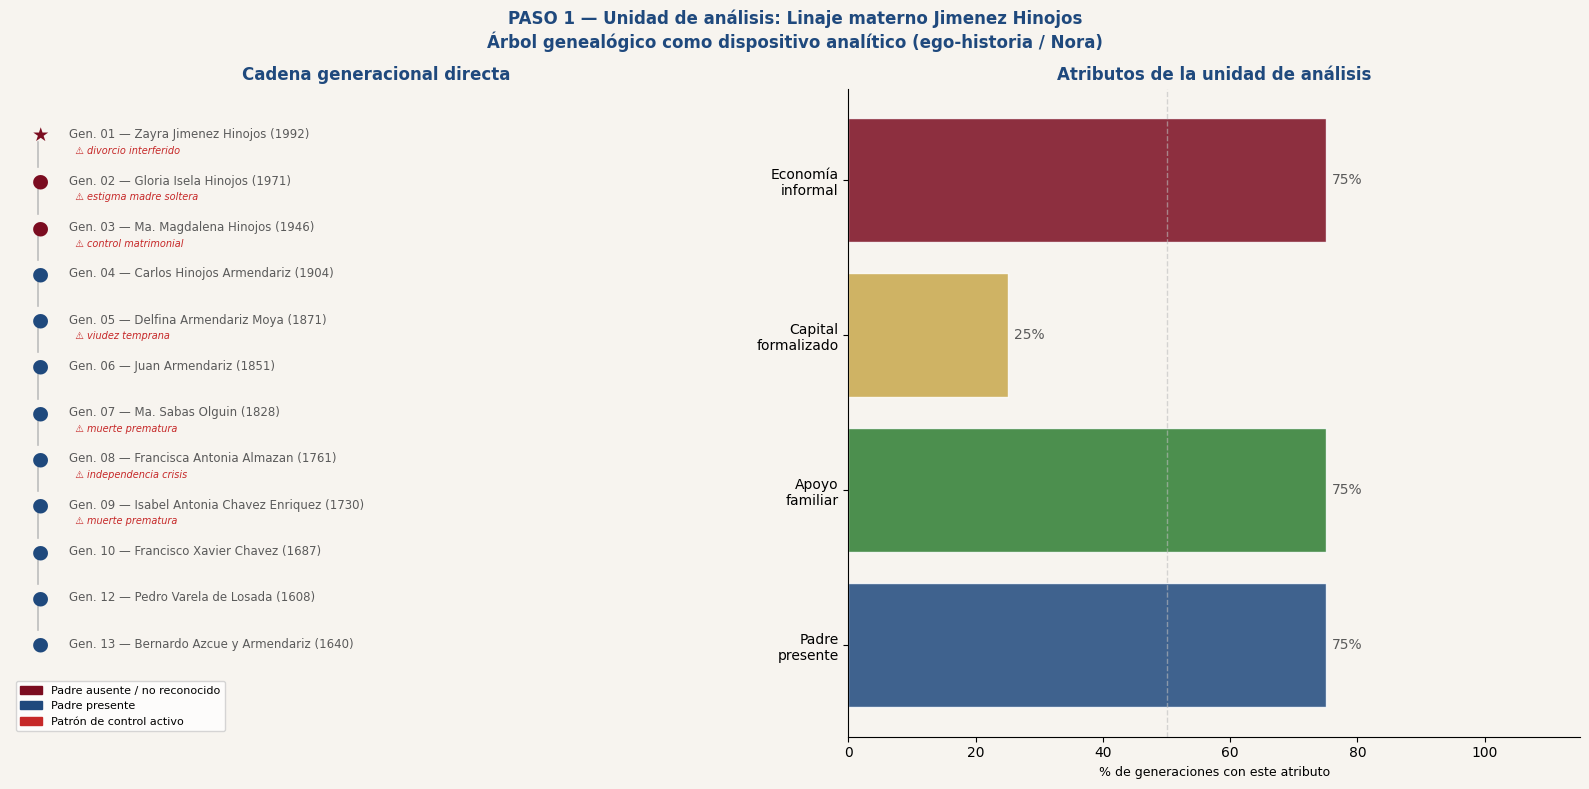


──────────────────────────────────────────────────
PASO 2: PATRONES REPETIDOS
──────────────────────────────────────────────────
✓ Paso 2 guardado: ZAJH_paso2_patrones_repetidos_20260428_0421.png


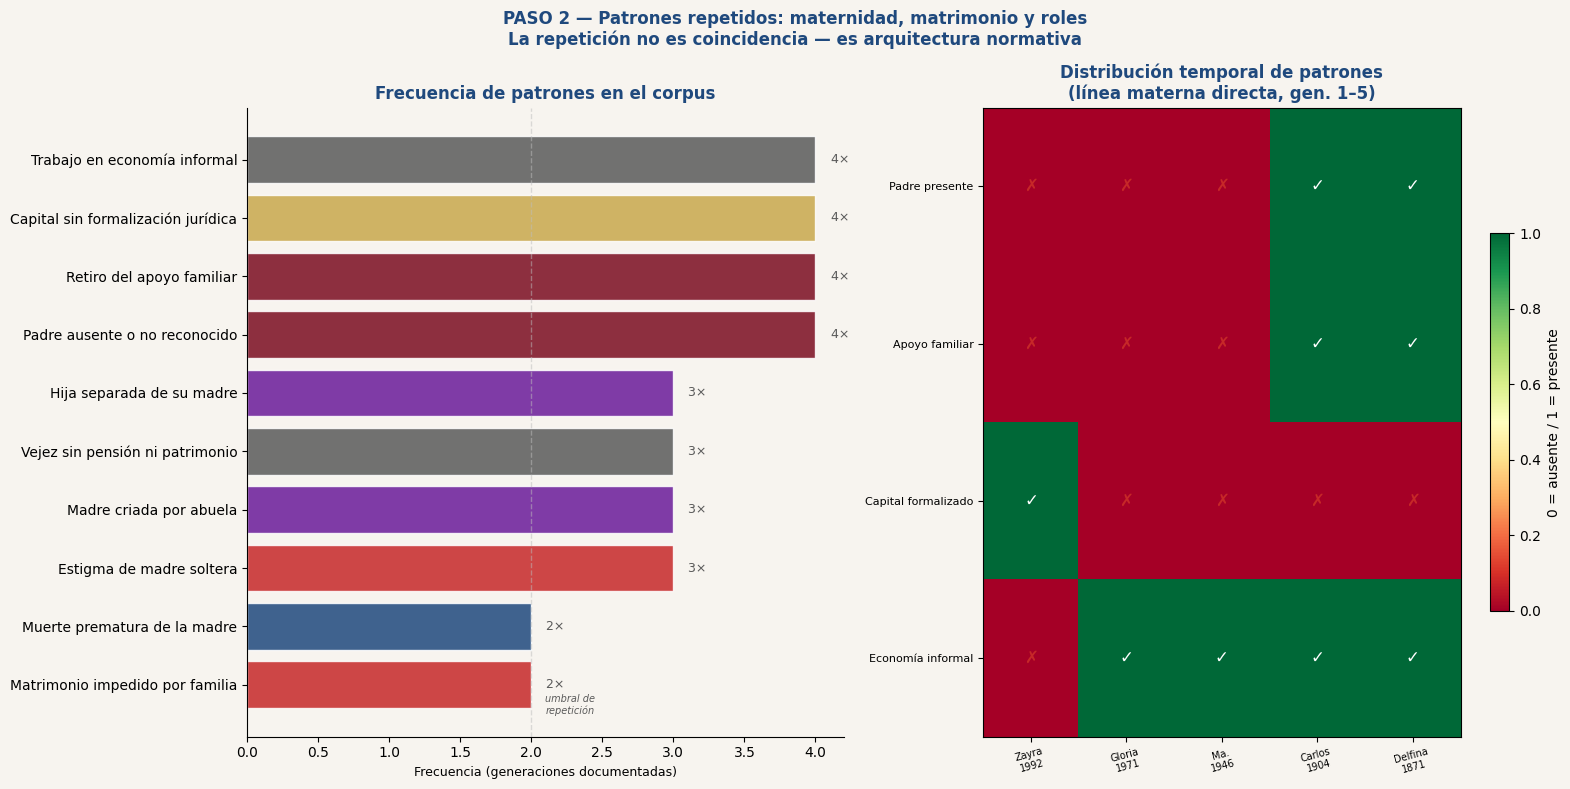


──────────────────────────────────────────────────
PASO 3: INSTITUCIONES INFLUYENTES
──────────────────────────────────────────────────
✓ Paso 3 guardado: ZAJH_paso3_instituciones_20260428_0421.png


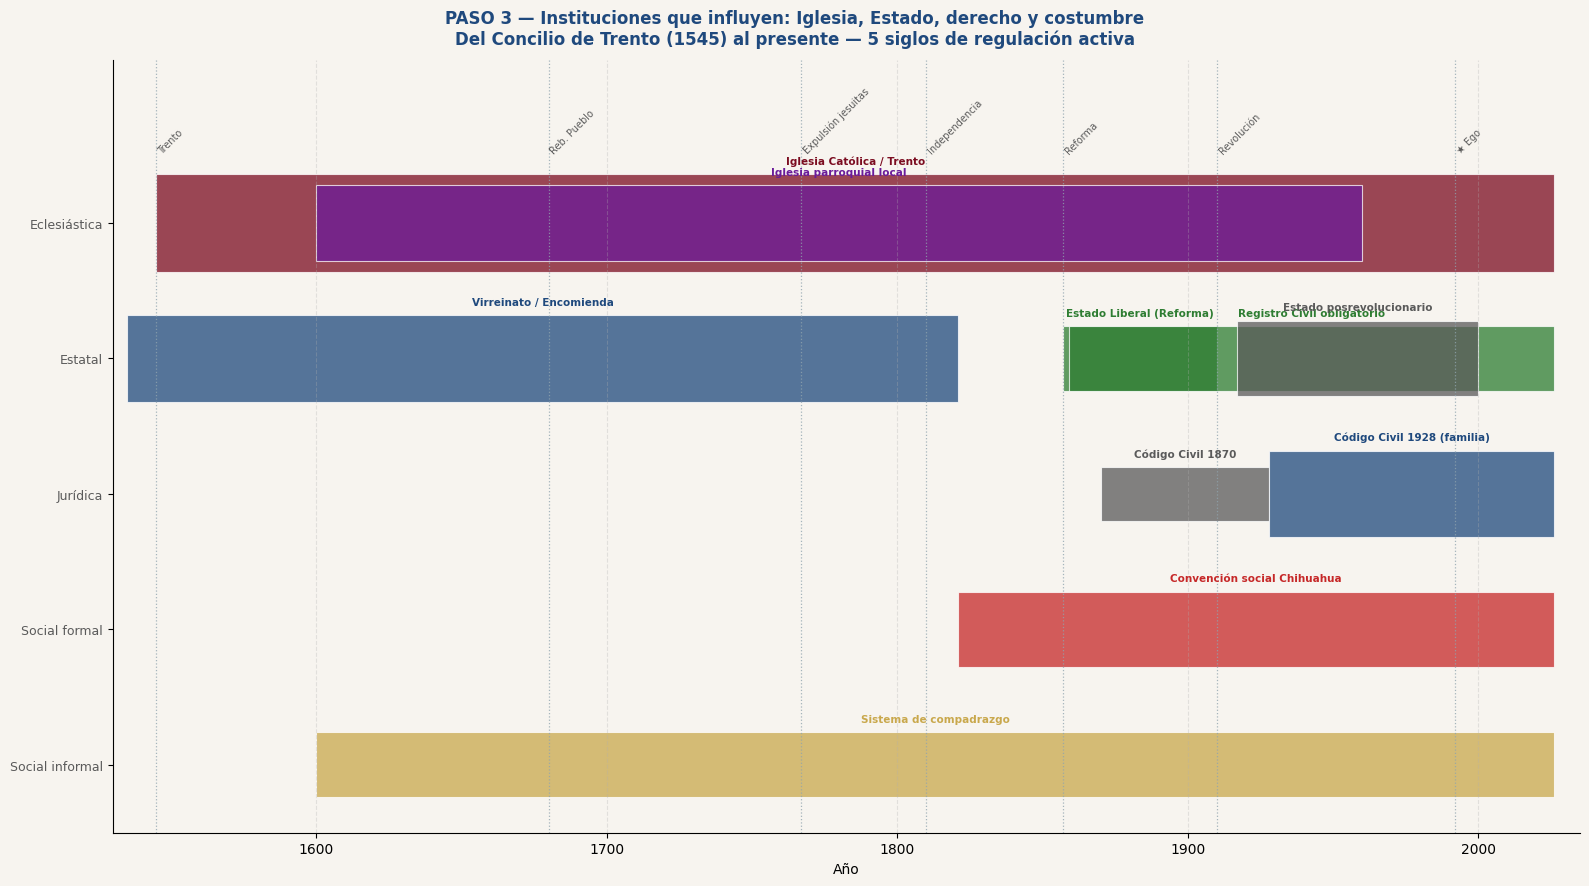


──────────────────────────────────────────────────
PASO 4: BUCLES RETROALIMENTACIÓN
──────────────────────────────────────────────────
✓ Paso 4 guardado: ZAJH_paso4_bucles_retroalimentacion_20260428_0422.png


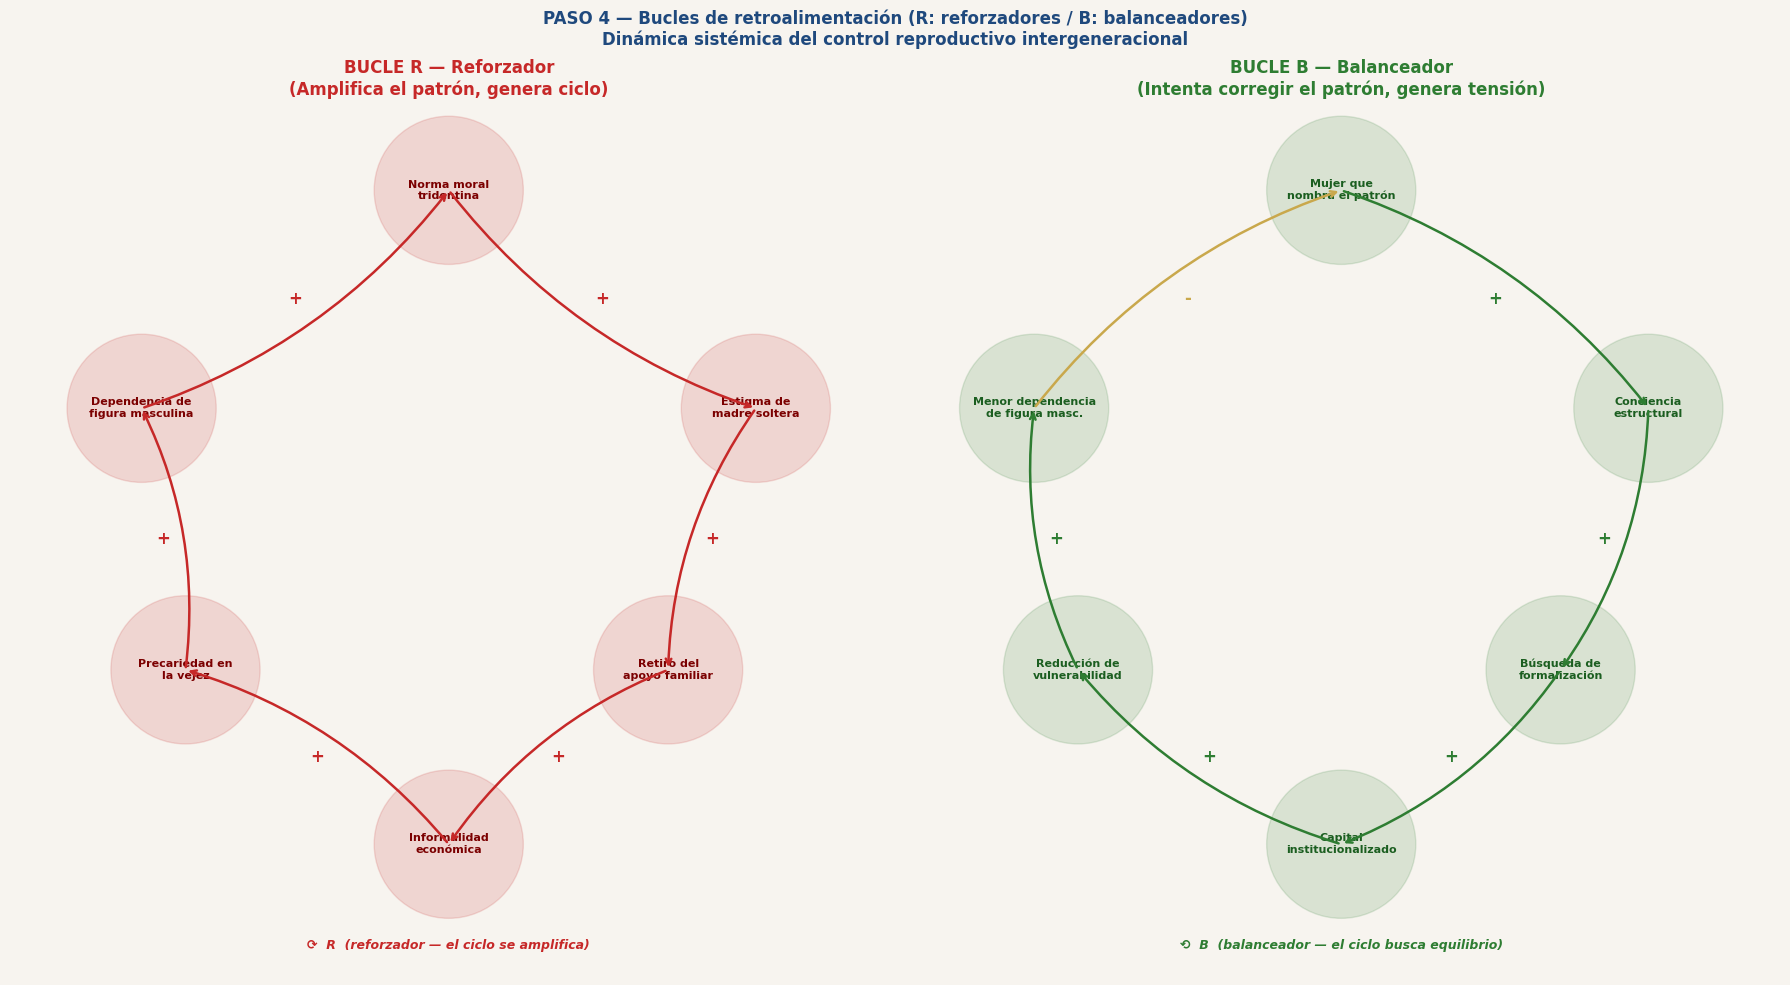


──────────────────────────────────────────────────
PASO 5: RUPTURAS GENERACIONALES
──────────────────────────────────────────────────
✓ Paso 5 guardado: ZAJH_paso5_rupturas_20260428_0422.png


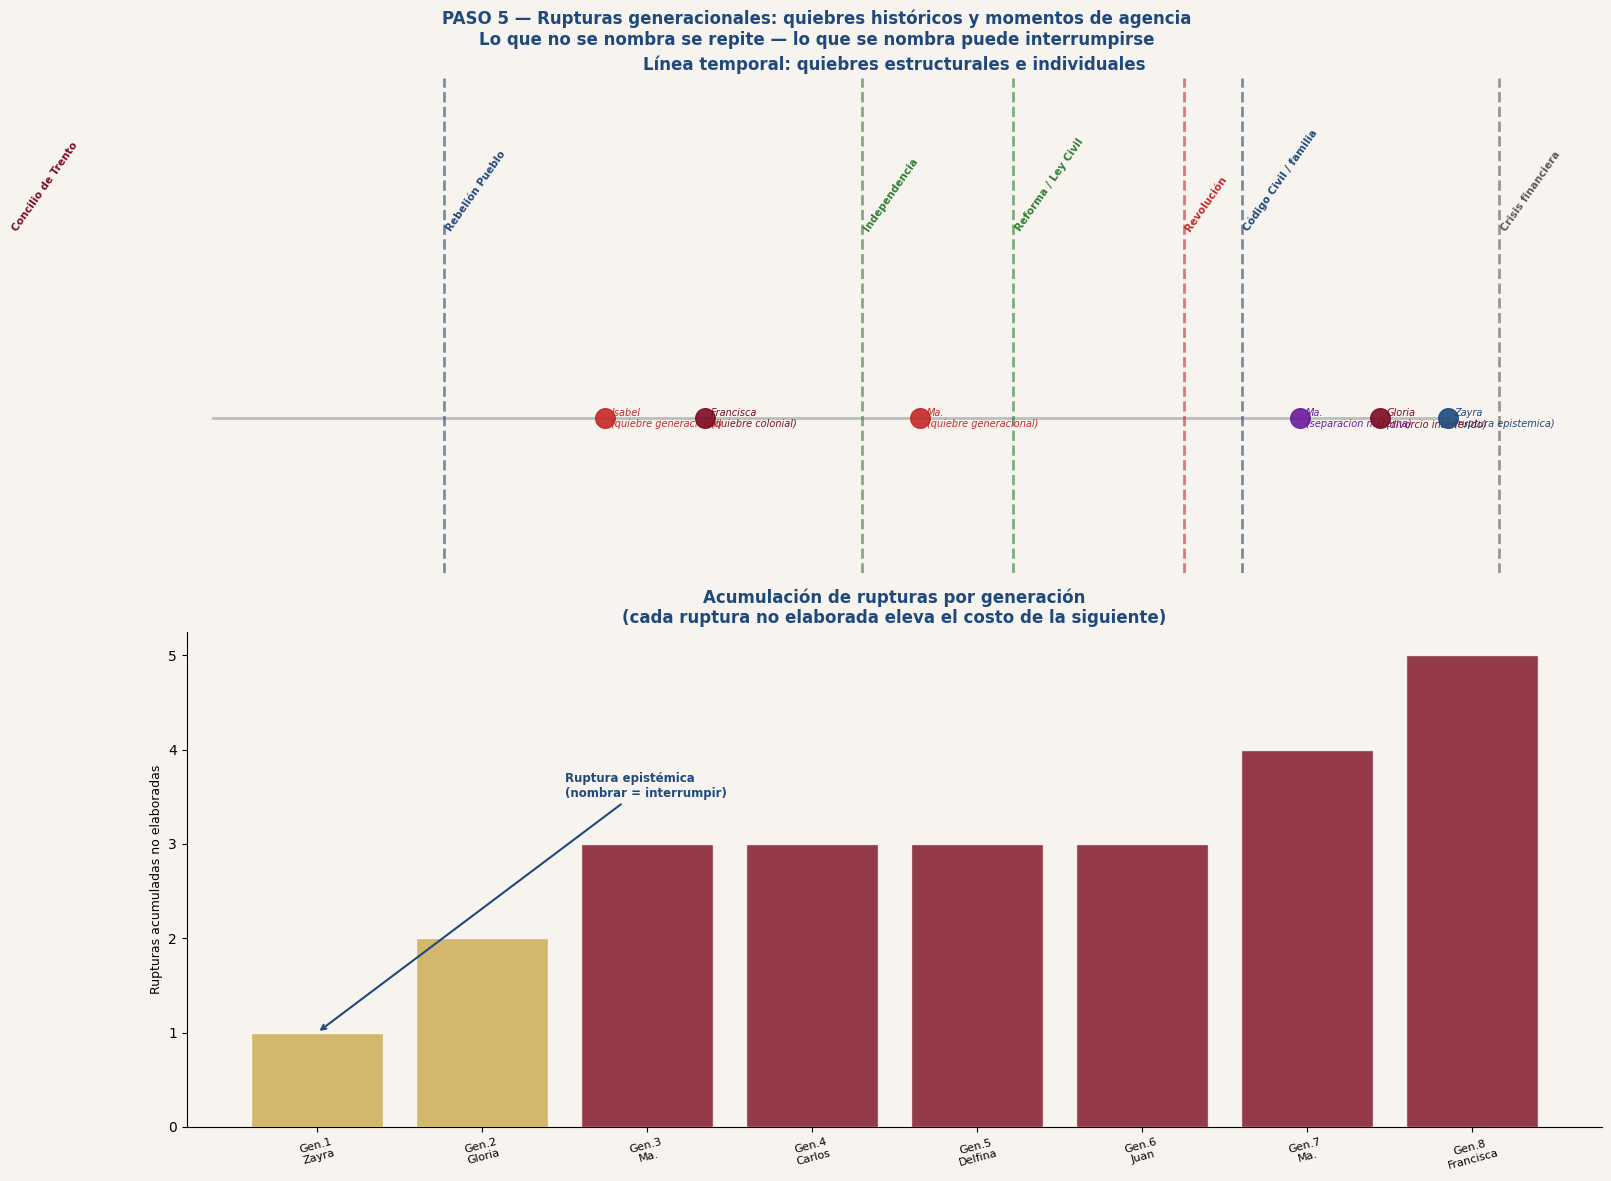


──────────────────────────────────────────────────
PASO 6: MECANISMO DE CONTROL SOCIAL
──────────────────────────────────────────────────
✓ Paso 6 guardado: ZAJH_paso6_mecanismo_control_20260428_0422.png


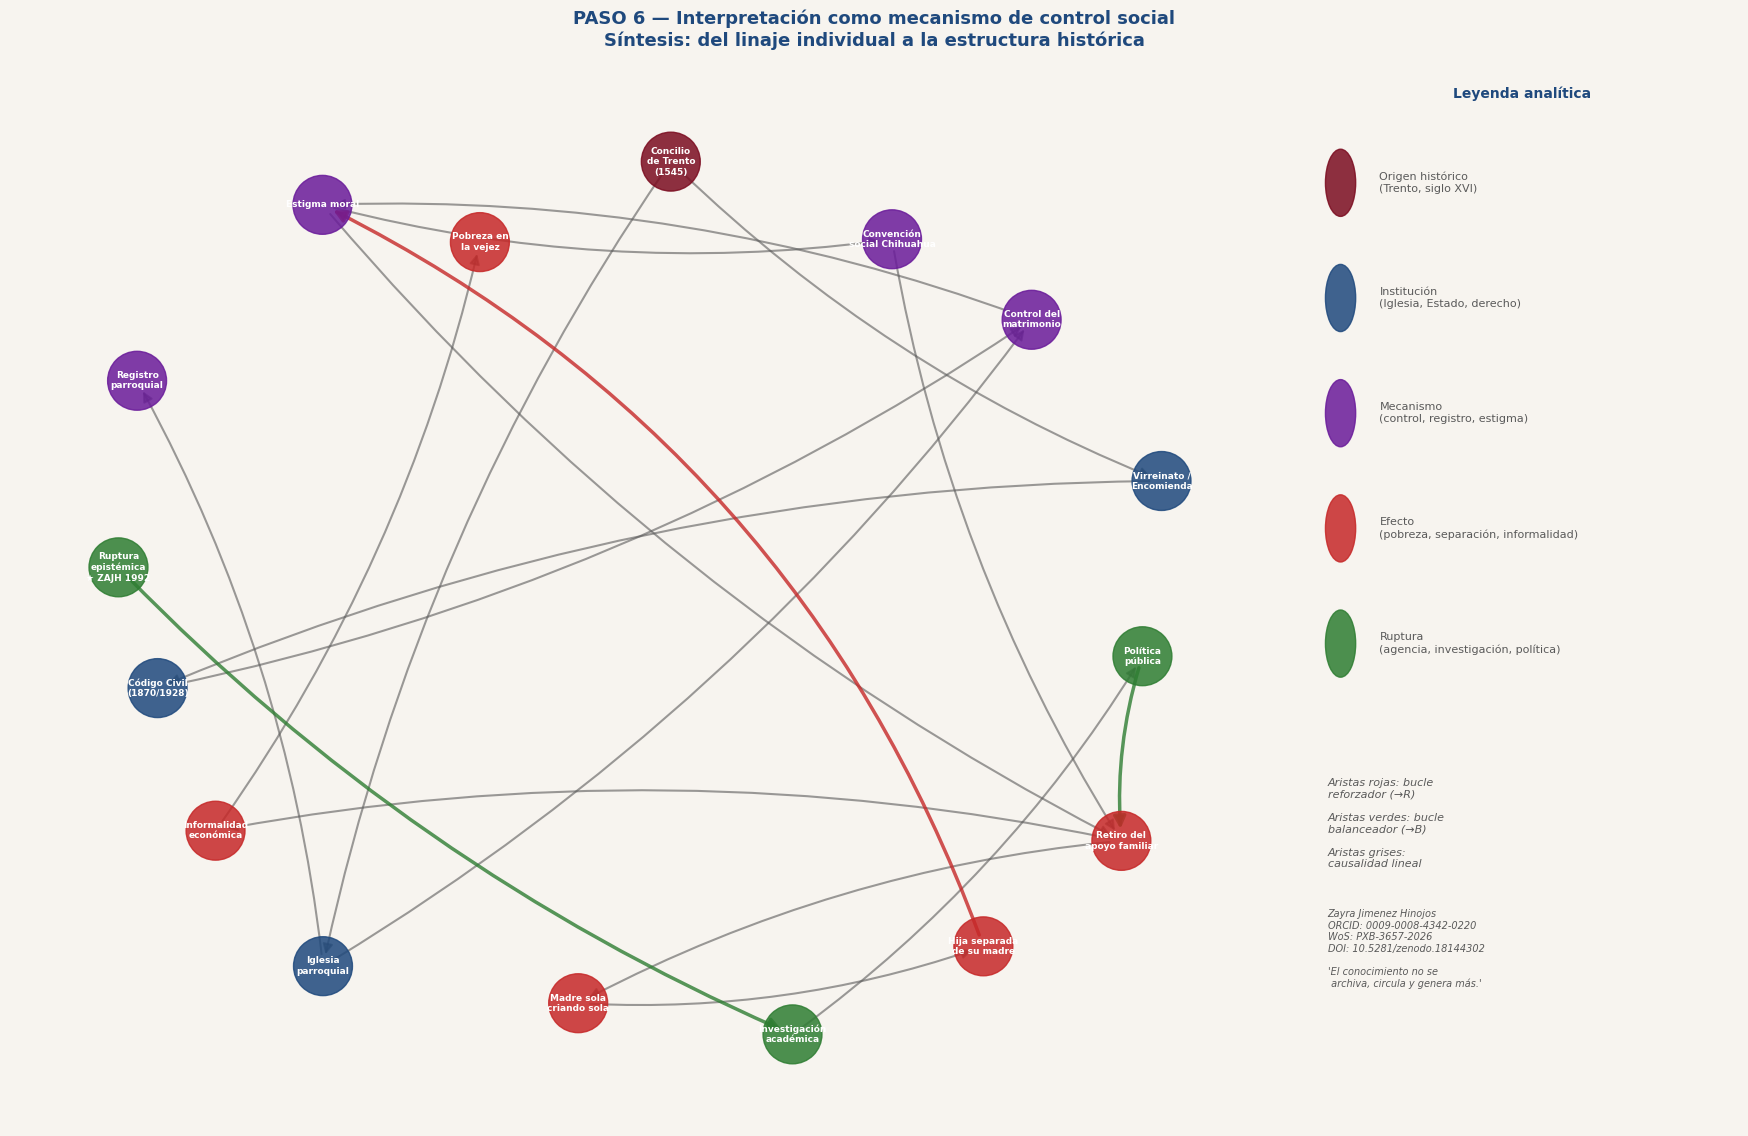


PIPELINE COMPLETADO
Archivos generados: 6
  ✓ ZAJH_paso1_unidad_analisis_20260428_0421.png
  ✓ ZAJH_paso2_patrones_repetidos_20260428_0421.png
  ✓ ZAJH_paso3_instituciones_20260428_0421.png
  ✓ ZAJH_paso4_bucles_retroalimentacion_20260428_0422.png
  ✓ ZAJH_paso5_rupturas_20260428_0422.png
  ✓ ZAJH_paso6_mecanismo_control_20260428_0422.png

Citación:
Jimenez Hinojos, Z. (2026). Algoritmo de mapeo microhistórico:
maternidad y control social en el linaje Jimenez Hinojos.
Zenodo. https://doi.org/10.5281/zenodo.18144302
ORCID: 0009-0008-4342-0220 | WoS: PXB-3657-2026


In [2]:
# ============================================================
# ALGORITMO DE MAPEO PARA ESTUDIO DE CASO MICROHISTÓRICO
# Linaje Jimenez Hinojos — Maternidad y Control Social
#
# Autora: Zayra Jimenez Hinojos
# ORCID: 0009-0008-4342-0220
# WoS: PXB-3657-2026
# DOI: 10.5281/zenodo.18144302
# Versión: 1.0 — Abril 2026
# Licencia: CC BY-NC-ND 4.0
#
# PIPELINE DE 6 PASOS:
# 1. Identificar unidad de análisis (familia / linaje)
# 2. Detectar patrones repetidos (maternidad, matrimonio, roles)
# 3. Ubicar instituciones que influyen (Iglesia, Estado)
# 4. Mapear bucles de retroalimentación (R y B)
# 5. Identificar rupturas generacionales
# 6. Interpretar como mecanismo de control social
# ============================================================

# !pip install networkx matplotlib seaborn pandas numpy scipy
# !pip install geopandas folium

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
import networkx as nx
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# --- Paleta institucional ZAJH ---
AZUL    = "#1F497D"
GRANATE = "#7B0C20"
DORADO  = "#C9A84C"
GRIS    = "#5A5A5A"
VERDE   = "#2E7D32"
ROJO    = "#C62828"
MORADO  = "#6A1B9A"
FONDO   = "#F7F4EF"

def ts():
    return datetime.now().strftime("%Y%m%d_%H%M")

def titulo_global(fig, texto):
    fig.suptitle(texto, fontsize=13, fontweight="bold",
                 color=AZUL, y=1.01)

# ============================================================
# DATOS BASE DEL CORPUS
# ============================================================

LINAJE = pd.DataFrame([
    # gen, nombre, anio, lugar, patron_control, tipo_ruptura,
    # padre_presente, apoyo_familiar, formaliz_capital, informalidad
    [1, "Zayra Jimenez Hinojos",          1992, "Chihuahua",
     "divorcio_interferido",    "ruptura_epistemica",
     False, False, True,  False],
    [2, "Gloria Isela Hinojos",            1971, "Chihuahua",
     "estigma_madre_soltera",   "divorcio_interferido",
     False, False, False, True],
    [3, "Ma. Magdalena Hinojos",           1946, "Allende",
     "control_matrimonial",     "separacion_materna",
     False, False, False, True],
    [4, "Carlos Hinojos Armendariz",       1904, "Parral",
     None,                      None,
     True,  True,  False, True],
    [5, "Delfina Armendariz Moya",         1871, "Allende",
     "viudez_temprana",         None,
     True,  True,  False, True],
    [6, "Juan Armendariz",                 1851, "Allende",
     None,                      None,
     True,  True,  False, True],
    [7, "Ma. Sabas Olguin",                1828, "Allende",
     "muerte_prematura",        "quiebre_generacional",
     True,  True,  False, True],
    [8, "Francisca Antonia Almazan",       1761, "Allende",
     "independencia_crisis",    "quiebre_colonial",
     True,  True,  False, True],
    [9, "Isabel Antonia Chavez Enriquez",  1730, "Parral",
     "muerte_prematura",        "quiebre_generacional",
     True,  True,  False, True],
    [10,"Francisco Xavier Chavez",         1687, "Parral",
     None,                      None,
     True,  True,  False, True],
    [12,"Pedro Varela de Losada",          1608, "S. Bartolome",
     None,                      None,
     True,  True,  True,  False],
    [13,"Bernardo Azcue y Armendariz",     1640, "Navarra→Allende",
     None,                      None,
     True,  True,  True,  False],
], columns=[
    "generacion", "nombre", "anio", "lugar",
    "patron_control", "tipo_ruptura",
    "padre_presente", "apoyo_familiar",
    "formaliz_capital", "informalidad"
])

# Instituciones con períodos de influencia y tipo
INSTITUCIONES = pd.DataFrame([
    ["Iglesia Católica / Trento",   1545, 2026, "eclesiastica",  9,  GRANATE],
    ["Virreinato / Encomienda",     1535, 1821, "estatal",       8,  AZUL],
    ["Estado Liberal (Reforma)",    1857, 1910, "estatal",       6,  VERDE],
    ["Iglesia parroquial local",    1600, 1960, "eclesiastica",  7,  MORADO],
    ["Código Civil 1870",           1870, 1928, "juridica",      5,  GRIS],
    ["Sistema de compadrazgo",      1600, 2026, "social_informal",6, DORADO],
    ["Convención social Chihuahua", 1821, 2026, "social_formal", 7,  ROJO],
    ["Código Civil 1928 (familia)", 1928, 2026, "juridica",      8,  AZUL],
    ["Registro Civil obligatorio",  1859, 2026, "estatal",       6,  VERDE],
    ["Estado posrevolucionario",    1917, 2000, "estatal",       7,  GRIS],
], columns=["nombre", "inicio", "fin", "tipo", "intensidad", "color"])

# Patrones repetidos con frecuencia y categoría
PATRONES = pd.DataFrame([
    ["Padre ausente o no reconocido",      4, "filiacion",    GRANATE],
    ["Madre criada por abuela",            3, "cuidado",      MORADO],
    ["Matrimonio impedido por familia",    2, "matrimonio",   ROJO],
    ["Estigma de madre soltera",           3, "moral",        ROJO],
    ["Retiro del apoyo familiar",          4, "apoyo",        GRANATE],
    ["Trabajo en economía informal",       4, "economia",     GRIS],
    ["Muerte prematura de la madre",       2, "demografico",  AZUL],
    ["Capital sin formalización jurídica", 4, "capital",      DORADO],
    ["Hija separada de su madre",          3, "cuidado",      MORADO],
    ["Vejez sin pensión ni patrimonio",    3, "vejez",        GRIS],
], columns=["patron", "frecuencia", "categoria", "color"])

# ============================================================
# PASO 1: UNIDAD DE ANÁLISIS
# ============================================================
def paso1_unidad_analisis():
    """
    Visualiza la unidad de análisis: el linaje femenino
    como cadena generacional con sus atributos clave.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor=FONDO)
    fig.suptitle(
        "PASO 1 — Unidad de análisis: Linaje materno Jimenez Hinojos\n"
        "Árbol genealógico como dispositivo analítico (ego-historia / Nora)",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # --- Panel A: cadena generacional ---
    ax1 = axes[0]
    ax1.set_facecolor(FONDO)
    ax1.set_xlim(0, 10)
    ax1.set_ylim(-1, len(LINAJE) + 1)
    ax1.axis("off")
    ax1.set_title("Cadena generacional directa", color=AZUL, fontweight="bold")

    for i, (_, fila) in enumerate(LINAJE.iterrows()):
        y = len(LINAJE) - i
        color = GRANATE if fila["padre_presente"] == False else AZUL
        marcador = "★" if fila["generacion"] == 1 else "●"
        ax1.text(0.3, y, marcador, fontsize=14, color=color, va="center")
        ax1.text(0.8, y,
                 f"Gen. {int(fila['generacion']):02d} — {fila['nombre']} ({fila['anio']})",
                 fontsize=8.5, color=GRIS, va="center")
        if fila["patron_control"]:
            ax1.text(0.8, y - 0.35,
                     f"  ⚠ {fila['patron_control'].replace('_', ' ')}",
                     fontsize=7, color=ROJO, va="center", style="italic")
        if i < len(LINAJE) - 1:
            ax1.plot([0.38, 0.38], [y - 0.15, y - 0.7],
                     color="#BDBDBD", linewidth=1.2)

    leyenda = [
        mpatches.Patch(color=GRANATE, label="Padre ausente / no reconocido"),
        mpatches.Patch(color=AZUL,    label="Padre presente"),
        mpatches.Patch(color=ROJO,    label="Patrón de control activo"),
    ]
    ax1.legend(handles=leyenda, loc="lower left", fontsize=8)

    # --- Panel B: atributos de la unidad ---
    ax2 = axes[1]
    ax2.set_facecolor(FONDO)
    ax2.set_title("Atributos de la unidad de análisis", color=AZUL, fontweight="bold")

    categorias = ["Padre\npresente", "Apoyo\nfamiliar",
                  "Capital\nformalizado", "Economía\ninformal"]
    valores_si = [
        LINAJE["padre_presente"].mean() * 100,
        LINAJE["apoyo_familiar"].mean() * 100,
        LINAJE["formaliz_capital"].mean() * 100,
        LINAJE["informalidad"].mean() * 100,
    ]
    colores_bar = [AZUL, VERDE, DORADO, GRANATE]
    bars = ax2.barh(categorias, valores_si, color=colores_bar, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, valores_si):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f"{val:.0f}%", va="center", fontsize=10, color=GRIS)
    ax2.set_xlim(0, 115)
    ax2.set_xlabel("% de generaciones con este atributo", fontsize=9)
    ax2.axvline(50, color="#BDBDBD", linestyle="--", linewidth=1, alpha=0.6)
    ax2.set_facecolor(FONDO)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    plt.tight_layout()
    nombre = f"ZAJH_paso1_unidad_analisis_{ts()}.png"
    plt.savefig(nombre, dpi=200, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Paso 1 guardado: {nombre}")
    plt.show()
    return nombre

# ============================================================
# PASO 2: PATRONES REPETIDOS
# ============================================================
def paso2_patrones_repetidos():
    """
    Detecta y visualiza los patrones que se repiten
    en maternidad, matrimonio y roles de género.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor=FONDO)
    fig.suptitle(
        "PASO 2 — Patrones repetidos: maternidad, matrimonio y roles\n"
        "La repetición no es coincidencia — es arquitectura normativa",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Panel A: frecuencia de patrones
    ax1 = axes[0]
    ax1.set_facecolor(FONDO)
    df_orden = PATRONES.sort_values("frecuencia", ascending=True)
    ax1.barh(df_orden["patron"], df_orden["frecuencia"],
             color=df_orden["color"], alpha=0.85, edgecolor="white")
    ax1.set_xlabel("Frecuencia (generaciones documentadas)", fontsize=9)
    ax1.set_title("Frecuencia de patrones en el corpus", color=AZUL, fontweight="bold")
    ax1.axvline(2, color="#BDBDBD", linestyle="--", linewidth=1, alpha=0.5)
    ax1.text(2.1, -0.5, "umbral de\nrepetición", fontsize=7, color=GRIS, style="italic")
    for i, (_, row) in enumerate(df_orden.iterrows()):
        ax1.text(row["frecuencia"] + 0.05, i,
                 f"  {row['frecuencia']}×", va="center", fontsize=9, color=GRIS)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.set_facecolor(FONDO)

    # Panel B: mapa de calor por generación y patrón
    ax2 = axes[1]
    ax2.set_facecolor(FONDO)
    ax2.set_title("Distribución temporal de patrones\n(línea materna directa, gen. 1–5)",
                  color=AZUL, fontweight="bold")

    # Matriz de presencia/ausencia
    gens_directas = LINAJE[LINAJE["generacion"] <= 5].copy()
    patrones_clave = [
        "padre_presente", "apoyo_familiar",
        "formaliz_capital", "informalidad"
    ]
    etiquetas = [
        "Padre presente", "Apoyo familiar",
        "Capital formalizado", "Economía informal"
    ]
    matriz = gens_directas[patrones_clave].astype(int).values
    nombres_cortos = [n.split()[0] + "\n" + str(a)
                      for n, a in zip(gens_directas["nombre"], gens_directas["anio"])]

    im = ax2.imshow(matriz.T, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    ax2.set_xticks(range(len(gens_directas)))
    ax2.set_xticklabels(nombres_cortos, fontsize=7, rotation=15)
    ax2.set_yticks(range(len(patrones_clave)))
    ax2.set_yticklabels(etiquetas, fontsize=8)
    for i in range(len(patrones_clave)):
        for j in range(len(gens_directas)):
            val = matriz[j, i]
            ax2.text(j, i, "✓" if val else "✗",
                     ha="center", va="center",
                     fontsize=12,
                     color="white" if val else "#C62828")
    plt.colorbar(im, ax=ax2, shrink=0.6,
                 label="0 = ausente / 1 = presente")

    plt.tight_layout()
    nombre = f"ZAJH_paso2_patrones_repetidos_{ts()}.png"
    plt.savefig(nombre, dpi=200, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Paso 2 guardado: {nombre}")
    plt.show()
    return nombre

# ============================================================
# PASO 3: INSTITUCIONES QUE INFLUYEN
# ============================================================
def paso3_instituciones():
    """
    Mapea las instituciones (Iglesia, Estado, derecho,
    costumbre) y su período de influencia sobre el linaje.
    """
    fig, ax = plt.subplots(figsize=(16, 9), facecolor=FONDO)
    ax.set_facecolor(FONDO)
    fig.suptitle(
        "PASO 3 — Instituciones que influyen: Iglesia, Estado, derecho y costumbre\n"
        "Del Concilio de Trento (1545) al presente — 5 siglos de regulación activa",
        fontsize=12, fontweight="bold", color=AZUL
    )

    tipos_y = {
        "eclesiastica":   4,
        "estatal":        3,
        "juridica":       2,
        "social_formal":  1,
        "social_informal":0,
    }
    etiq_tipo = {
        "eclesiastica":   "Eclesiástica",
        "estatal":        "Estatal",
        "juridica":       "Jurídica",
        "social_formal":  "Social formal",
        "social_informal":"Social informal",
    }

    for _, inst in INSTITUCIONES.iterrows():
        y = tipos_y[inst["tipo"]]
        ancho = inst["fin"] - inst["inicio"]
        grosor = inst["intensidad"] * 0.08
        ax.barh(y, ancho, left=inst["inicio"],
                height=grosor, color=inst["color"],
                alpha=0.75, edgecolor="white", linewidth=0.8)
        mid = inst["inicio"] + ancho / 2
        ax.text(mid, y + grosor / 2 + 0.06,
                inst["nombre"], ha="center", va="bottom",
                fontsize=7.5, color=inst["color"], fontweight="bold")

    # Eventos históricos clave
    eventos = {
        1545: "Trento",
        1680: "Reb. Pueblo",
        1767: "Expulsión jesuitas",
        1810: "Independencia",
        1857: "Reforma",
        1910: "Revolución",
        1992: "★ Ego",
    }
    for anio, desc in eventos.items():
        ax.axvline(anio, color="#90A4AE", linewidth=0.9,
                   linestyle=":", alpha=0.8)
        ax.text(anio, 4.5, desc, rotation=45, fontsize=7,
                color=GRIS, ha="left", va="bottom")

    ax.set_yticks(list(tipos_y.values()))
    ax.set_yticklabels([etiq_tipo[k] for k in tipos_y],
                       fontsize=9, color=GRIS)
    ax.set_xlim(1530, 2035)
    ax.set_ylim(-0.5, 5.2)
    ax.set_xlabel("Año", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    nombre = f"ZAJH_paso3_instituciones_{ts()}.png"
    plt.savefig(nombre, dpi=200, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Paso 3 guardado: {nombre}")
    plt.show()
    return nombre

# ============================================================
# PASO 4: BUCLES DE RETROALIMENTACIÓN (R y B)
# ============================================================
def paso4_bucles_retroalimentacion():
    """
    Construye el grafo de bucles de retroalimentación:
    R = reforzadores (amplifican el patrón)
    B = balanceadores (intentan romperlo)
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 10), facecolor=FONDO)
    fig.suptitle(
        "PASO 4 — Bucles de retroalimentación (R: reforzadores / B: balanceadores)\n"
        "Dinámica sistémica del control reproductivo intergeneracional",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # ---- BUCLE R: Reforzador (el que perpetúa) ----
    ax1 = axes[0]
    ax1.set_facecolor(FONDO)
    ax1.set_title("BUCLE R — Reforzador\n(Amplifica el patrón, genera ciclo)",
                  color=ROJO, fontweight="bold")
    ax1.axis("off")
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)

    nodos_R = {
        "Norma moral\ntridentina":           (5, 9),
        "Estigma de\nmadre soltera":          (8.5, 6.5),
        "Retiro del\napoyo familiar":         (7.5, 3.5),
        "Informalidad\neconómica":            (5, 1.5),
        "Precariedad en\nla vejez":           (2, 3.5),
        "Dependencia de\nfigura masculina":   (1.5, 6.5),
    }

    aristas_R = [
        ("Norma moral\ntridentina",        "Estigma de\nmadre soltera",     "+"),
        ("Estigma de\nmadre soltera",       "Retiro del\napoyo familiar",    "+"),
        ("Retiro del\napoyo familiar",      "Informalidad\neconómica",       "+"),
        ("Informalidad\neconómica",         "Precariedad en\nla vejez",      "+"),
        ("Precariedad en\nla vejez",        "Dependencia de\nfigura masculina","+"),
        ("Dependencia de\nfigura masculina","Norma moral\ntridentina",       "+"),
    ]

    for nodo, (x, y) in nodos_R.items():
        ax1.add_patch(plt.Circle((x, y), 0.85,
                                  color=ROJO, alpha=0.15, zorder=1))
        ax1.text(x, y, nodo, ha="center", va="center",
                 fontsize=8, color="#7B0000", fontweight="bold", zorder=3)

    for origen, destino, signo in aristas_R:
        x1, y1 = nodos_R[origen]
        x2, y2 = nodos_R[destino]
        ax1.annotate("",
            xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->", color=ROJO,
                            lw=1.8, connectionstyle="arc3,rad=0.15"))
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax1.text(mx, my, signo, fontsize=12, color=ROJO,
                 ha="center", va="center", fontweight="bold")

    ax1.text(5, 0.3, "⟳  R  (reforzador — el ciclo se amplifica)",
             ha="center", fontsize=9, color=ROJO,
             fontweight="bold", style="italic")

    # ---- BUCLE B: Balanceador (el que intenta romper) ----
    ax2 = axes[1]
    ax2.set_facecolor(FONDO)
    ax2.set_title("BUCLE B — Balanceador\n(Intenta corregir el patrón, genera tensión)",
                  color=VERDE, fontweight="bold")
    ax2.axis("off")
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 10)

    nodos_B = {
        "Mujer que\nnombra el patrón":       (5, 9),
        "Conciencia\nestructural":            (8.5, 6.5),
        "Búsqueda de\nformalización":         (7.5, 3.5),
        "Capital\ninstitucionalizado":         (5, 1.5),
        "Reducción de\nvulnerabilidad":        (2, 3.5),
        "Menor dependencia\nde figura masc.":  (1.5, 6.5),
    }

    aristas_B = [
        ("Mujer que\nnombra el patrón",      "Conciencia\nestructural",       "+"),
        ("Conciencia\nestructural",           "Búsqueda de\nformalización",    "+"),
        ("Búsqueda de\nformalización",        "Capital\ninstitucionalizado",   "+"),
        ("Capital\ninstitucionalizado",        "Reducción de\nvulnerabilidad",  "+"),
        ("Reducción de\nvulnerabilidad",       "Menor dependencia\nde figura masc.","+"),
        ("Menor dependencia\nde figura masc.","Mujer que\nnombra el patrón",   "-"),
    ]

    for nodo, (x, y) in nodos_B.items():
        ax2.add_patch(plt.Circle((x, y), 0.85,
                                  color=VERDE, alpha=0.15, zorder=1))
        ax2.text(x, y, nodo, ha="center", va="center",
                 fontsize=8, color="#1B5E20", fontweight="bold", zorder=3)

    for origen, destino, signo in aristas_B:
        x1, y1 = nodos_B[origen]
        x2, y2 = nodos_B[destino]
        color_a = VERDE if signo == "+" else DORADO
        ax2.annotate("",
            xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->", color=color_a,
                            lw=1.8, connectionstyle="arc3,rad=-0.15"))
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax2.text(mx, my, signo, fontsize=12, color=color_a,
                 ha="center", va="center", fontweight="bold")

    ax2.text(5, 0.3, "⟲  B  (balanceador — el ciclo busca equilibrio)",
             ha="center", fontsize=9, color=VERDE,
             fontweight="bold", style="italic")

    plt.tight_layout()
    nombre = f"ZAJH_paso4_bucles_retroalimentacion_{ts()}.png"
    plt.savefig(nombre, dpi=200, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Paso 4 guardado: {nombre}")
    plt.show()
    return nombre

# ============================================================
# PASO 5: RUPTURAS GENERACIONALES
# ============================================================
def paso5_rupturas():
    """
    Identifica y visualiza los puntos de ruptura:
    quiebres históricos + rupturas individuales + la
    ruptura epistémica final.
    """
    fig, axes = plt.subplots(2, 1, figsize=(16, 12), facecolor=FONDO)
    fig.suptitle(
        "PASO 5 — Rupturas generacionales: quiebres históricos y momentos de agencia\n"
        "Lo que no se nombra se repite — lo que se nombra puede interrumpirse",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Panel A: línea temporal con rupturas
    ax1 = axes[0]
    ax1.set_facecolor(FONDO)
    ax1.set_title("Línea temporal: quiebres estructurales e individuales",
                  color=AZUL, fontweight="bold")

    quiebres_hist = {
        1545: ("Concilio de Trento", GRANATE),
        1680: ("Rebelión Pueblo", AZUL),
        1810: ("Independencia", VERDE),
        1857: ("Reforma / Ley Civil", VERDE),
        1910: ("Revolución", ROJO),
        1928: ("Código Civil / familia", AZUL),
        2008: ("Crisis financiera", GRIS),
    }

    for anio, (desc, color) in quiebres_hist.items():
        ax1.axvline(anio, color=color, linewidth=2,
                    linestyle="--", alpha=0.6)
        ax1.text(anio, 1.1, desc, rotation=55,
                 fontsize=7.5, color=color, ha="left", va="bottom",
                 fontweight="bold")

    # Rupturas individuales del linaje
    rupturas_ind = LINAJE[LINAJE["tipo_ruptura"].notna()].copy()
    colores_ruptura = {
        "quiebre_generacional": ROJO,
        "quiebre_colonial":     GRANATE,
        "separacion_materna":   MORADO,
        "divorcio_interferido": GRANATE,
        "ruptura_epistemica":   AZUL,
    }
    for _, fila in rupturas_ind.iterrows():
        color = colores_ruptura.get(fila["tipo_ruptura"], GRIS)
        ax1.scatter(fila["anio"], 0.5, s=200, color=color,
                    zorder=5, alpha=0.9)
        ax1.text(fila["anio"] + 2, 0.5,
                 f"{fila['nombre'].split()[0]}\n({fila['tipo_ruptura'].replace('_',' ')})",
                 fontsize=7, color=color, va="center", style="italic")

    # Línea de vida del linaje
    linaje_ord = LINAJE.sort_values("anio")
    ax1.plot(linaje_ord["anio"], [0.5] * len(linaje_ord),
             color="#BDBDBD", linewidth=2, zorder=1)
    ax1.set_ylim(0, 1.6)
    ax1.set_xlim(1600, 2040)
    ax1.axis("off")

    # Panel B: diagrama de escaleras (acumulación de rupturas)
    ax2 = axes[1]
    ax2.set_facecolor(FONDO)
    ax2.set_title(
        "Acumulación de rupturas por generación\n"
        "(cada ruptura no elaborada eleva el costo de la siguiente)",
        color=AZUL, fontweight="bold"
    )

    gens = LINAJE[LINAJE["generacion"] <= 8].sort_values("generacion")
    rupturas_acum = []
    acum = 0
    for _, fila in gens.iterrows():
        if pd.notna(fila["tipo_ruptura"]):
            acum += 1
        rupturas_acum.append(acum)

    colores_esc = [GRANATE if r > 2 else DORADO if r > 0 else VERDE
                   for r in rupturas_acum]
    bars = ax2.bar(range(len(gens)), rupturas_acum,
                   color=colores_esc, alpha=0.8, edgecolor="white")
    ax2.set_xticks(range(len(gens)))
    ax2.set_xticklabels(
        [f"Gen.{int(g['generacion'])}\n{g['nombre'].split()[0]}"
         for _, g in gens.iterrows()],
        fontsize=8, rotation=15
    )
    ax2.set_ylabel("Rupturas acumuladas no elaboradas", fontsize=9)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.set_facecolor(FONDO)

    # Marcar la ruptura epistémica
    ax2.annotate("Ruptura epistémica\n(nombrar = interrumpir)",
        xy=(0, rupturas_acum[0]),
        xytext=(1.5, 3.5),
        arrowprops=dict(arrowstyle="->", color=AZUL, lw=1.5),
        fontsize=8.5, color=AZUL, fontweight="bold")

    plt.tight_layout()
    nombre = f"ZAJH_paso5_rupturas_{ts()}.png"
    plt.savefig(nombre, dpi=200, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Paso 5 guardado: {nombre}")
    plt.show()
    return nombre

# ============================================================
# PASO 6: INTERPRETACIÓN COMO MECANISMO DE CONTROL SOCIAL
# ============================================================
def paso6_mecanismo_control():
    """
    Sintetiza los cinco pasos anteriores en una
    interpretación estructural: el linaje como evidencia
    de un mecanismo histórico de control social.
    """
    fig = plt.figure(figsize=(18, 12), facecolor=FONDO)
    fig.suptitle(
        "PASO 6 — Interpretación como mecanismo de control social\n"
        "Síntesis: del linaje individual a la estructura histórica",
        fontsize=13, fontweight="bold", color=AZUL
    )

    # ---- Grafo sistémico integrado ----
    G = nx.DiGraph()

    nodos = {
        # (label, tipo)
        "Concilio\nde Trento\n(1545)":         "origen",
        "Virreinato /\nEncomienda":             "institucion",
        "Iglesia\nparroquial":                  "institucion",
        "Registro\nparroquial":                 "mecanismo",
        "Control del\nmatrimonio":              "mecanismo",
        "Estigma moral":                        "mecanismo",
        "Retiro del\napoyo familiar":           "efecto",
        "Informalidad\neconómica":              "efecto",
        "Pobreza en\nla vejez":                 "efecto",
        "Madre sola\ncriando sola":             "efecto",
        "Hija separada\nde su madre":           "efecto",
        "Código Civil\n(1870/1928)":            "institucion",
        "Convención\nsocial Chihuahua":         "mecanismo",
        "Ruptura\nepistémica\n★ ZAJH 1992":     "ruptura",
        "Investigación\nacadémica":             "ruptura",
        "Política\npública":                    "ruptura",
    }

    aristas = [
        ("Concilio\nde Trento\n(1545)",    "Virreinato /\nEncomienda",      "transmite"),
        ("Concilio\nde Trento\n(1545)",    "Iglesia\nparroquial",           "articula"),
        ("Iglesia\nparroquial",             "Registro\nparroquial",          "opera vía"),
        ("Iglesia\nparroquial",             "Control del\nmatrimonio",       "regula"),
        ("Virreinato /\nEncomienda",        "Código Civil\n(1870/1928)",    "deriva en"),
        ("Código Civil\n(1870/1928)",       "Control del\nmatrimonio",      "formaliza"),
        ("Control del\nmatrimonio",         "Estigma moral",                "produce"),
        ("Estigma moral",                   "Retiro del\napoyo familiar",   "activa"),
        ("Estigma moral",                   "Convención\nsocial Chihuahua", "refuerza"),
        ("Convención\nsocial Chihuahua",    "Retiro del\napoyo familiar",   "amplifica"),
        ("Retiro del\napoyo familiar",      "Informalidad\neconómica",      "conduce a"),
        ("Retiro del\napoyo familiar",      "Madre sola\ncriando sola",     "produce"),
        ("Madre sola\ncriando sola",        "Hija separada\nde su madre",   "replica"),
        ("Informalidad\neconómica",         "Pobreza en\nla vejez",         "acumula en"),
        ("Hija separada\nde su madre",      "Estigma moral",                "reproduce →R"),
        ("Ruptura\nepistémica\n★ ZAJH 1992","Investigación\nacadémica",    "genera"),
        ("Investigación\nacadémica",        "Política\npública",            "informa"),
        ("Política\npública",               "Retiro del\napoyo familiar",   "puede corregir"),
    ]

    for nodo in nodos:
        G.add_node(nodo)
    for o, d, etiq in aristas:
        G.add_edge(o, d, label=etiq)

    colores_tipo = {
        "origen":      GRANATE,
        "institucion": AZUL,
        "mecanismo":   MORADO,
        "efecto":      ROJO,
        "ruptura":     VERDE,
    }
    node_colors = [colores_tipo[nodos[n]] for n in G.nodes()]

    pos = nx.spring_layout(G, seed=42, k=2.5)

    ax = fig.add_axes([0.02, 0.05, 0.70, 0.88])
    ax.set_facecolor(FONDO)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=1800, alpha=0.85)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=6.5,
                            font_color="white", font_weight="bold")

    # Aristas con colores por tipo
    aristas_ruptura = [(o, d) for o, d, e in aristas if o.startswith("Ruptura") or
                        o.startswith("Investigacion") or o.startswith("Política")]
    aristas_refuerzo = [(o, d) for o, d, e in aristas if "→R" in e]
    aristas_normales = [(o, d) for o, d, e in aristas
                        if (o, d) not in aristas_ruptura and
                           (o, d) not in aristas_refuerzo]

    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=aristas_normales,
                           edge_color=GRIS, arrows=True, arrowsize=15,
                           width=1.5, alpha=0.6,
                           connectionstyle="arc3,rad=0.1")
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=aristas_refuerzo,
                           edge_color=ROJO, arrows=True, arrowsize=18,
                           width=2.5, alpha=0.8,
                           connectionstyle="arc3,rad=0.2")
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=aristas_ruptura,
                           edge_color=VERDE, arrows=True, arrowsize=18,
                           width=2.5, alpha=0.8,
                           connectionstyle="arc3,rad=0.1")
    ax.axis("off")

    # Leyenda lateral
    ax_ley = fig.add_axes([0.74, 0.1, 0.24, 0.80])
    ax_ley.set_facecolor(FONDO)
    ax_ley.axis("off")
    ax_ley.set_title("Leyenda analítica", color=AZUL,
                     fontweight="bold", fontsize=10)

    leyenda_nodos = [
        (GRANATE, "Origen histórico\n(Trento, siglo XVI)"),
        (AZUL,    "Institución\n(Iglesia, Estado, derecho)"),
        (MORADO,  "Mecanismo\n(control, registro, estigma)"),
        (ROJO,    "Efecto\n(pobreza, separación, informalidad)"),
        (VERDE,   "Ruptura\n(agencia, investigación, política)"),
    ]
    for i, (color, desc) in enumerate(leyenda_nodos):
        y = 0.92 - i * 0.12
        ax_ley.add_patch(plt.Circle((0.08, y), 0.035,
                                     color=color, alpha=0.85,
                                     transform=ax_ley.transAxes))
        ax_ley.text(0.17, y, desc, va="center", fontsize=8,
                    color=GRIS, transform=ax_ley.transAxes)

    ax_ley.text(0.05, 0.30,
        "Aristas rojas: bucle\nreforzador (→R)\n\n"
        "Aristas verdes: bucle\nbalanceador (→B)\n\n"
        "Aristas grises:\ncausalidad lineal",
        fontsize=8, color=GRIS, transform=ax_ley.transAxes,
        va="top", style="italic")

    ax_ley.text(0.05, 0.08,
        "Zayra Jimenez Hinojos\n"
        "ORCID: 0009-0008-4342-0220\n"
        "WoS: PXB-3657-2026\n"
        "DOI: 10.5281/zenodo.18144302\n\n"
        "'El conocimiento no se\n archiva, circula y genera más.'",
        fontsize=7, color=GRIS, transform=ax_ley.transAxes,
        va="bottom", style="italic")

    nombre = f"ZAJH_paso6_mecanismo_control_{ts()}.png"
    plt.savefig(nombre, dpi=200, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Paso 6 guardado: {nombre}")
    plt.show()
    return nombre

# ============================================================
# PIPELINE COMPLETO
# ============================================================
def ejecutar_pipeline_completo():
    print("=" * 60)
    print("PIPELINE MICROHISTÓRICO — ÁRBOL JIMENEZ HINOJOS")
    print("Zayra Jimenez Hinojos | ORCID: 0009-0008-4342-0220")
    print("=" * 60)

    archivos = []
    pasos = [
        (1, "Unidad de análisis",        paso1_unidad_analisis),
        (2, "Patrones repetidos",         paso2_patrones_repetidos),
        (3, "Instituciones influyentes",  paso3_instituciones),
        (4, "Bucles retroalimentación",   paso4_bucles_retroalimentacion),
        (5, "Rupturas generacionales",    paso5_rupturas),
        (6, "Mecanismo de control social",paso6_mecanismo_control),
    ]

    for num, desc, func in pasos:
        print(f"\n{'─'*50}")
        print(f"PASO {num}: {desc.upper()}")
        print(f"{'─'*50}")
        archivo = func()
        archivos.append(archivo)

    print("\n" + "=" * 60)
    print("PIPELINE COMPLETADO")
    print("=" * 60)
    print(f"Archivos generados: {len(archivos)}")
    for a in archivos:
        print(f"  ✓ {a}")
    print("\nCitación:")
    print(
        "Jimenez Hinojos, Z. (2026). Algoritmo de mapeo microhistórico:\n"
        "maternidad y control social en el linaje Jimenez Hinojos.\n"
        "Zenodo. https://doi.org/10.5281/zenodo.18144302\n"
        "ORCID: 0009-0008-4342-0220 | WoS: PXB-3657-2026"
    )
    return archivos

# ============================================================
# EJECUCIÓN
# ============================================================
if __name__ == "__main__":
    ejecutar_pipeline_completo()

In [4]:
ejecutar_todo()        # ambos algoritmos
# o por separado:
ejecutar_algoritmo_invisibilizacion()
ejecutar_algoritmo_politicas()

NameError: name 'ejecutar_todo' is not defined

ZAJH — PIPELINE COMPLETO DE ALGORITMOS
Zayra Jimenez Hinojos | ORCID: 0009-0008-4342-0220
WoS: PXB-3657-2026 | DOI: 10.5281/zenodo.18144302

ALGORITMO II — INVISIBILIZACIÓN DOCUMENTAL FEMENINA

─────────────────────────────────────────────
1. AUSENCIA DE REGISTROS
─────────────────────────────────────────────
✓ Invisibilización Paso 1: ZAJH_invis_paso1_20260428_0422.png


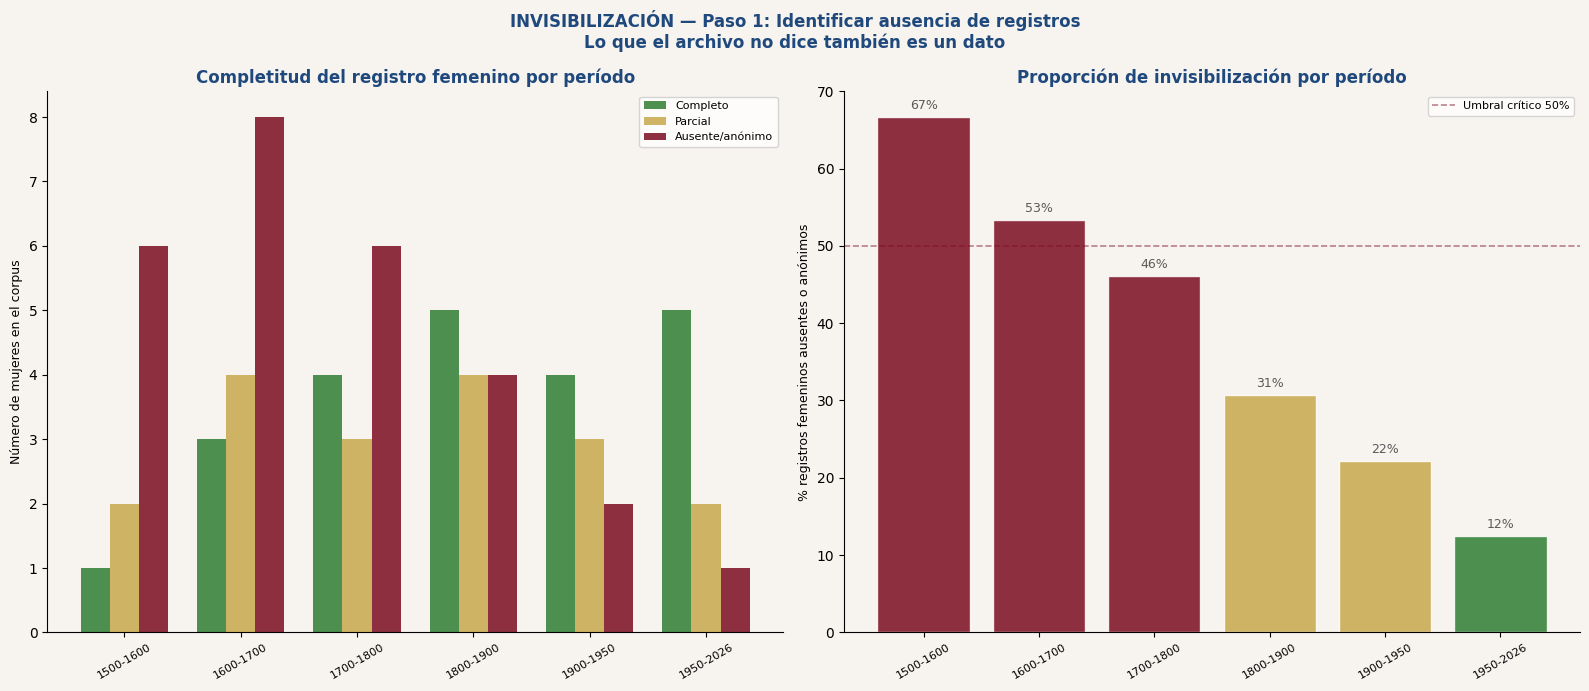


─────────────────────────────────────────────
2. COMPARACIÓN MASCULINA
─────────────────────────────────────────────
✓ Invisibilización Paso 2: ZAJH_invis_paso2_20260428_0422.png


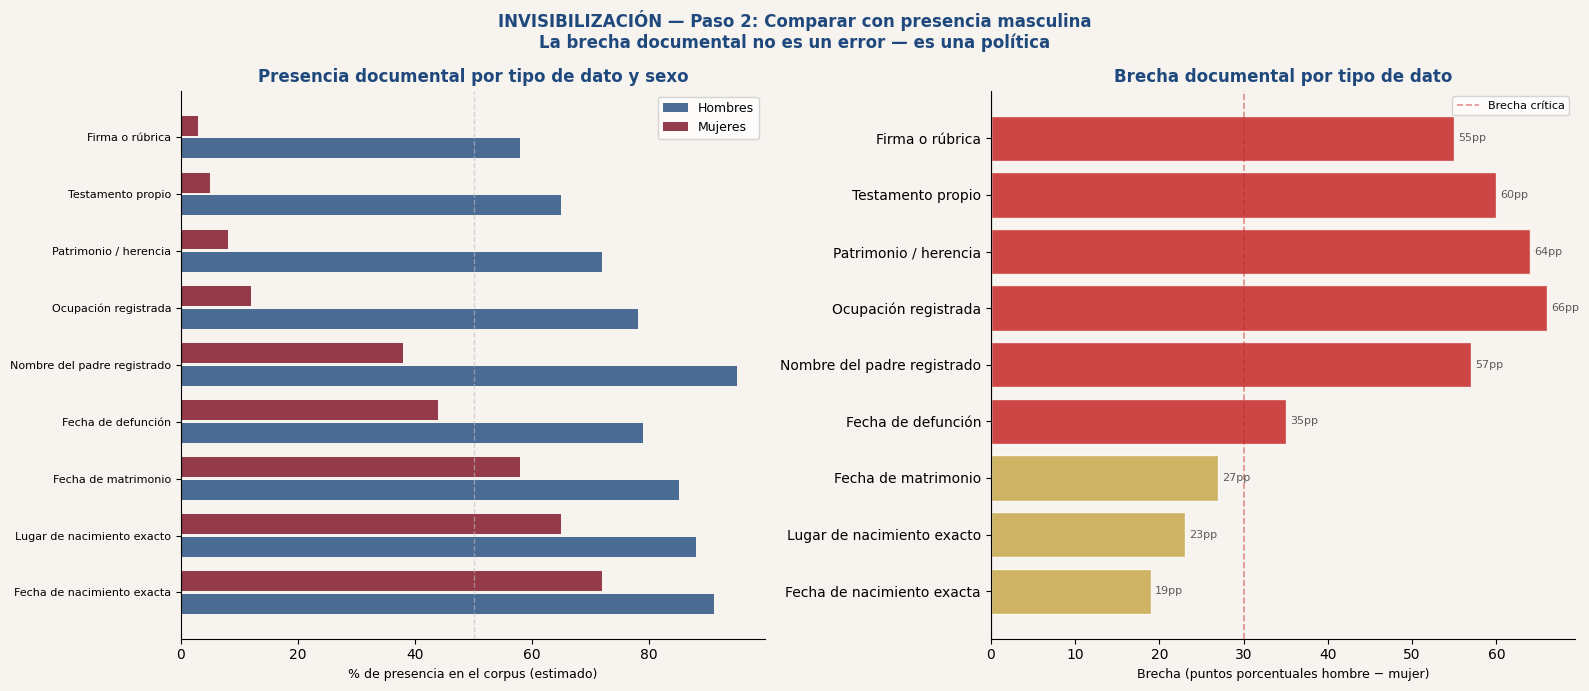


─────────────────────────────────────────────
3. CONTEXTO INSTITUCIONAL
─────────────────────────────────────────────


KeyError: 'demografica'

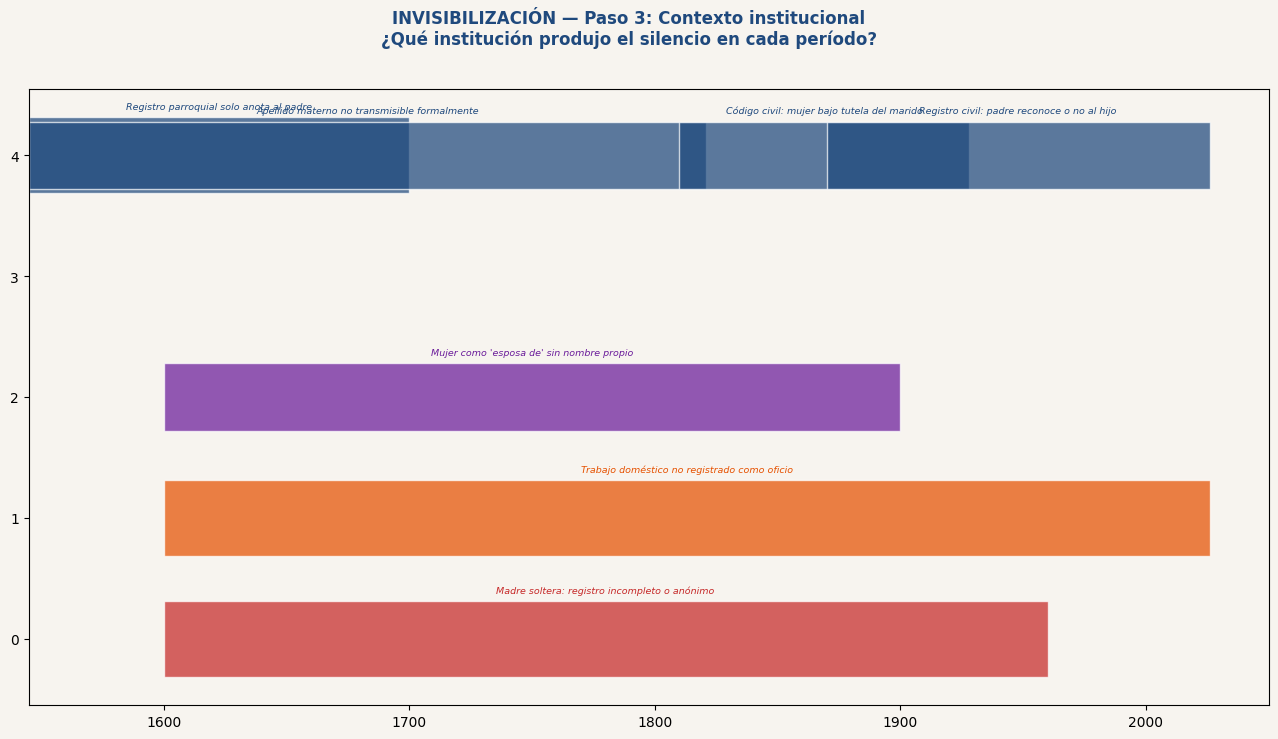

In [5]:
# ============================================================
# ALGORITMO II: INVISIBILIZACIÓN DOCUMENTAL FEMENINA
# ALGORITMO III: ANÁLISIS DE POLÍTICAS PÚBLICAS Y LOOPS DE PODER
#
# Árbol Jimenez Hinojos — Maternidad y Control Social
# Autora: Zayra Jimenez Hinojos
# ORCID: 0009-0008-4342-0220
# WoS: PXB-3657-2026
# DOI: 10.5281/zenodo.18144302
# Versión: 1.0 — Abril 2026
# Licencia: CC BY-NC-ND 4.0
#
# ALGORITMO II — INVISIBILIZACIÓN:
# 1. Identificar ausencia de registros
# 2. Comparar con presencia masculina
# 3. Ubicar contexto institucional
# 4. Analizar causas de invisibilización
# 5. Detectar patrones sistemáticos
# 6. Interpretar como mecanismo
#
# ALGORITMO III — POLÍTICAS PÚBLICAS:
# 1. Definir problema público
# 2. Identificar actores (Estado, población)
# 3. Detectar intervención (programa/política)
# 4. Analizar instrumentos (educación, salud, subsidio)
# 5. Evaluar efectos (cambio o no cambio)
# 6. Identificar loops de poder (qué se refuerza o rompe)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# --- Paleta ZAJH ---
AZUL    = "#1F497D"
GRANATE = "#7B0C20"
DORADO  = "#C9A84C"
GRIS    = "#5A5A5A"
VERDE   = "#2E7D32"
ROJO    = "#C62828"
MORADO  = "#6A1B9A"
NARANJA = "#E65100"
FONDO   = "#F7F4EF"

def ts():
    return datetime.now().strftime("%Y%m%d_%H%M")

# ============================================================
# DATOS — ALGORITMO II: INVISIBILIZACIÓN
# ============================================================

# Corpus de personas del árbol por período y sexo
CORPUS_REGISTROS = pd.DataFrame([
    # periodo, n_mujeres_completo, n_mujeres_parcial, n_mujeres_ausente,
    # n_hombres_completo, n_hombres_parcial, n_hombres_ausente
    ["1500-1600", 1,  2,  6,  4,  3,  2],
    ["1600-1700", 3,  4,  8,  7,  4,  2],
    ["1700-1800", 4,  3,  6,  8,  3,  1],
    ["1800-1900", 5,  4,  4,  9,  4,  2],
    ["1900-1950", 4,  3,  2,  6,  3,  1],
    ["1950-2026", 5,  2,  1,  4,  2,  0],
], columns=[
    "periodo",
    "muj_completo", "muj_parcial", "muj_ausente",
    "hom_completo", "hom_parcial", "hom_ausente"
])

# Causas de invisibilización por período
CAUSAS_INVIS = pd.DataFrame([
    ["1545-1700", "Registro parroquial solo anota al padre",      9, "juridica"],
    ["1545-1821", "Apellido materno no transmisible formalmente", 8, "juridica"],
    ["1600-1900", "Mujer como 'esposa de' sin nombre propio",     8, "social"],
    ["1600-2026", "Trabajo doméstico no registrado como oficio",  9, "economica"],
    ["1810-1928", "Código civil: mujer bajo tutela del marido",   8, "juridica"],
    ["1600-1960", "Madre soltera: registro incompleto o anónimo", 9, "moral"],
    ["1870-2026", "Registro civil: padre reconoce o no al hijo",  8, "juridica"],
    ["1910-2026", "Migración interna: pérdida de documentos",     6, "demografica"],
    ["1990-2026", "Digitalización sesgada hacia hombres",         5, "tecnica"],
    ["1545-2026", "Iglesia: mujer como objeto de redención",      9, "eclesiastica"],
], columns=["periodo", "causa", "intensidad", "tipo"])

# Presencia relativa en el corpus genealógico por tipo de dato
PRESENCIA_DATOS = pd.DataFrame([
    ["Fecha de nacimiento exacta",  72, 91],
    ["Lugar de nacimiento exacto",  65, 88],
    ["Fecha de matrimonio",         58, 85],
    ["Fecha de defunción",          44, 79],
    ["Nombre del padre registrado", 38, 95],
    ["Ocupación registrada",        12, 78],
    ["Patrimonio / herencia",        8, 72],
    ["Testamento propio",            5, 65],
    ["Firma o rúbrica",              3, 58],
], columns=["tipo_dato", "presencia_mujeres_pct", "presencia_hombres_pct"])

# ============================================================
# DATOS — ALGORITMO III: POLÍTICAS PÚBLICAS
# ============================================================

POLITICAS = pd.DataFrame([
    # nombre, año, tipo_instrumento, actor_principal,
    # poblacion_obj, efecto_real, refuerza_o_rompe, intensidad
    ["Pensión para el Bienestar",      2019,
     "subsidio", "Estado federal",
     "adultos_mayores_65+",
     "ingreso_basico_sin_capital_social", "refuerza", 6],

    ["IMSS / Seguridad social formal", 1943,
     "contributivo", "Estado / empleador",
     "trabajador_formal",
     "excluye_economia_informal", "refuerza", 8],

    ["Registro Civil obligatorio",     1859,
     "juridico", "Estado liberal",
     "ciudadanía_formal",
     "invisibiliza_no_formalizados", "refuerza", 7],

    ["Programa Prospera / Oportunidades",1997,
     "condicionado", "Estado federal",
     "madres_en_pobreza",
     "transfiere_carga_a_mujer", "refuerza", 5],

    ["Ley General de Acceso (violencia)",2007,
     "juridico", "Estado / sociedad civil",
     "mujeres_en_situacion_violencia",
     "parcialmente_efectivo", "rompe_parcial", 4],

    ["Sistema Nacional de Cuidados",   2024,
     "estructural", "Estado / sociedad civil",
     "cuidadoras_no_remuneradas",
     "en_construccion", "rompe_potencial", 7],

    ["Digitalización de archivos AACH", 2015,
     "tecnico", "Estado Chihuahua",
     "investigadores_ciudadanos",
     "acceso_parcial_sesgado", "refuerza", 4],

    ["Tecnolochicas / STEM mujeres",   2015,
     "educativo", "sociedad_civil_empresas",
     "jovenes_mujeres",
     "ruptura_epistemica_generacional", "rompe", 6],

    ["Código Civil familia Chihuahua", 2022,
     "juridico", "Estado Chihuahua",
     "familias_diversas",
     "parcialmente_actualizad", "rompe_parcial", 5],

    ["ICPA (en desarrollo)",           2026,
     "indice_compuesto", "investigacion_independiente",
     "adultas_mayores_60+_Chihuahua",
     "mide_ejercicio_derechos", "rompe_potencial", 8],
], columns=[
    "nombre", "anio", "tipo_instrumento", "actor_principal",
    "poblacion_obj", "efecto_real", "refuerza_o_rompe", "intensidad"
])

# Actores del sistema
ACTORES = pd.DataFrame([
    ["Iglesia Católica",           "institucion_hist", 9,  GRANATE],
    ["Estado federal",             "estado",           8,  AZUL],
    ["Estado Chihuahua",           "estado",           6,  AZUL],
    ["Familia extensa",            "social_informal",  8,  MORADO],
    ["Sistema judicial",           "juridico",         7,  GRIS],
    ["Mercado laboral informal",   "economico",        7,  NARANJA],
    ["Madres solteras",            "poblacion_obj",    4,  ROJO],
    ["Adultas mayores 60+",        "poblacion_obj",    3,  ROJO],
    ["Sociedad civil / feminismos","agencia",          5,  VERDE],
    ["Investigadora (ZAJH)",       "agencia",          6,  VERDE],
    ["Tecnolochicas",              "agencia",          5,  VERDE],
    ["CONAPO / INEGI",             "tecnico",          6,  GRIS],
], columns=["actor", "tipo", "poder", "color"])

# ============================================================
# ============================================================
# ALGORITMO II — INVISIBILIZACIÓN DOCUMENTAL FEMENINA
# ============================================================
# ============================================================

def invis_paso1_ausencia_registros():
    """Paso 1: Identificar ausencia de registros femeninos."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=FONDO)
    fig.suptitle(
        "INVISIBILIZACIÓN — Paso 1: Identificar ausencia de registros\n"
        "Lo que el archivo no dice también es un dato",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Panel A: completitud por período
    ax1 = axes[0]
    ax1.set_facecolor(FONDO)
    periodos = CORPUS_REGISTROS["periodo"]
    x = np.arange(len(periodos))
    ancho = 0.25

    ax1.bar(x - ancho, CORPUS_REGISTROS["muj_completo"],
            ancho, label="Completo", color=VERDE, alpha=0.85)
    ax1.bar(x, CORPUS_REGISTROS["muj_parcial"],
            ancho, label="Parcial", color=DORADO, alpha=0.85)
    ax1.bar(x + ancho, CORPUS_REGISTROS["muj_ausente"],
            ancho, label="Ausente/anónimo", color=GRANATE, alpha=0.85)

    ax1.set_xticks(x)
    ax1.set_xticklabels(periodos, rotation=30, fontsize=8)
    ax1.set_ylabel("Número de mujeres en el corpus", fontsize=9)
    ax1.set_title("Completitud del registro femenino por período",
                  color=AZUL, fontweight="bold")
    ax1.legend(fontsize=8)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.set_facecolor(FONDO)

    # Panel B: % de registros ausentes por período
    ax2 = axes[1]
    ax2.set_facecolor(FONDO)
    total_muj = (CORPUS_REGISTROS["muj_completo"] +
                 CORPUS_REGISTROS["muj_parcial"] +
                 CORPUS_REGISTROS["muj_ausente"])
    pct_ausente = CORPUS_REGISTROS["muj_ausente"] / total_muj * 100

    bars = ax2.bar(periodos, pct_ausente,
                   color=[GRANATE if p > 40 else DORADO if p > 20 else VERDE
                          for p in pct_ausente],
                   alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, pct_ausente):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{val:.0f}%", ha="center", fontsize=9, color=GRIS)

    ax2.set_ylabel("% registros femeninos ausentes o anónimos", fontsize=9)
    ax2.set_title("Proporción de invisibilización por período",
                  color=AZUL, fontweight="bold")
    ax2.set_xticklabels(periodos, rotation=30, fontsize=8)
    ax2.axhline(50, color=GRANATE, linewidth=1.2,
                linestyle="--", alpha=0.5, label="Umbral crítico 50%")
    ax2.legend(fontsize=8)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.set_facecolor(FONDO)

    plt.tight_layout()
    n = f"ZAJH_invis_paso1_{ts()}.png"
    plt.savefig(n, dpi=180, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Invisibilización Paso 1: {n}")
    plt.show()
    return n


def invis_paso2_comparacion_masculina():
    """Paso 2: Comparar con presencia masculina."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=FONDO)
    fig.suptitle(
        "INVISIBILIZACIÓN — Paso 2: Comparar con presencia masculina\n"
        "La brecha documental no es un error — es una política",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Panel A: brecha por tipo de dato
    ax1 = axes[0]
    ax1.set_facecolor(FONDO)
    y = np.arange(len(PRESENCIA_DATOS))
    ax1.barh(y - 0.2, PRESENCIA_DATOS["presencia_hombres_pct"],
             0.35, color=AZUL, alpha=0.8, label="Hombres")
    ax1.barh(y + 0.2, PRESENCIA_DATOS["presencia_mujeres_pct"],
             0.35, color=GRANATE, alpha=0.8, label="Mujeres")
    ax1.set_yticks(y)
    ax1.set_yticklabels(PRESENCIA_DATOS["tipo_dato"], fontsize=8)
    ax1.set_xlabel("% de presencia en el corpus (estimado)", fontsize=9)
    ax1.set_title("Presencia documental por tipo de dato y sexo",
                  color=AZUL, fontweight="bold")
    ax1.legend(fontsize=9)
    ax1.axvline(50, color="#BDBDBD", linestyle="--", linewidth=1, alpha=0.6)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.set_facecolor(FONDO)

    # Panel B: brecha absoluta
    ax2 = axes[1]
    ax2.set_facecolor(FONDO)
    brecha = (PRESENCIA_DATOS["presencia_hombres_pct"] -
              PRESENCIA_DATOS["presencia_mujeres_pct"])
    colores_brecha = [ROJO if b > 30 else DORADO if b > 15 else VERDE
                      for b in brecha]
    bars = ax2.barh(PRESENCIA_DATOS["tipo_dato"], brecha,
                    color=colores_brecha, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, brecha):
        ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val:.0f}pp", va="center", fontsize=8, color=GRIS)
    ax2.set_xlabel("Brecha (puntos porcentuales hombre − mujer)", fontsize=9)
    ax2.set_title("Brecha documental por tipo de dato",
                  color=AZUL, fontweight="bold")
    ax2.axvline(0, color="#BDBDBD", linewidth=1)
    ax2.axvline(30, color=ROJO, linewidth=1.2,
                linestyle="--", alpha=0.5, label="Brecha crítica")
    ax2.legend(fontsize=8)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.set_facecolor(FONDO)

    plt.tight_layout()
    n = f"ZAJH_invis_paso2_{ts()}.png"
    plt.savefig(n, dpi=180, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Invisibilización Paso 2: {n}")
    plt.show()
    return n


def invis_paso3_contexto_institucional():
    """Paso 3: Ubicar contexto institucional de la invisibilización."""
    fig, ax = plt.subplots(figsize=(16, 8), facecolor=FONDO)
    ax.set_facecolor(FONDO)
    fig.suptitle(
        "INVISIBILIZACIÓN — Paso 3: Contexto institucional\n"
        "¿Qué institución produjo el silencio en cada período?",
        fontsize=12, fontweight="bold", color=AZUL
    )

    tipos_y = {
        "juridica":     4,
        "eclesiastica": 3,
        "social":       2,
        "economica":    1,
        "moral":        0,
    }
    etiq_y = {
        "juridica":     "Jurídica",
        "eclesiastica": "Eclesiástica",
        "social":       "Social",
        "economica":    "Económica",
        "moral":        "Moral / sexual",
    }
    colores_tipo = {
        "juridica":     AZUL,
        "eclesiastica": GRANATE,
        "social":       MORADO,
        "economica":    NARANJA,
        "moral":        ROJO,
    }

    for _, c in CAUSAS_INVIS.iterrows():
        y = tipos_y[c["tipo"]]
        # Parsear rango de período
        partes = c["periodo"].split("-")
        inicio = int(partes[0])
        fin    = int(partes[1])
        ancho  = fin - inicio
        grosor = c["intensidad"] * 0.07
        color  = colores_tipo[c["tipo"]]
        ax.barh(y, ancho, left=inicio,
                height=grosor, color=color,
                alpha=0.72, edgecolor="white")
        ax.text(inicio + ancho/2, y + grosor/2 + 0.05,
                c["causa"], ha="center", va="bottom",
                fontsize=6.8, color=color, style="italic")

    # Marcadores temporales
    for anio, desc in {1545:"Trento", 1810:"Indep.",
                        1857:"Reforma", 1928:"Cód.Civil",
                        1992:"★ZAJH"}.items():
        ax.axvline(anio, color="#90A4AE", linewidth=0.8,
                   linestyle=":", alpha=0.7)
        ax.text(anio+2, 4.7, desc, fontsize=7,
                color=GRIS, rotation=40, ha="left")

    ax.set_yticks(list(tipos_y.values()))
    ax.set_yticklabels([etiq_y[k] for k in tipos_y],
                       fontsize=9, color=GRIS)
    ax.set_xlim(1530, 2040)
    ax.set_ylim(-0.5, 5.1)
    ax.set_xlabel("Año", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    leyenda = [mpatches.Patch(color=c, label=etiq_y[t])
               for t, c in colores_tipo.items()]
    ax.legend(handles=leyenda, loc="lower right", fontsize=8)

    plt.tight_layout()
    n = f"ZAJH_invis_paso3_{ts()}.png"
    plt.savefig(n, dpi=180, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Invisibilización Paso 3: {n}")
    plt.show()
    return n


def invis_paso4_causas():
    """Paso 4: Analizar causas de invisibilización."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor=FONDO)
    fig.suptitle(
        "INVISIBILIZACIÓN — Paso 4: Causas de la invisibilización\n"
        "La ausencia en el archivo es el rastro de una decisión política",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Panel A: intensidad por causa
    ax1 = axes[0]
    ax1.set_facecolor(FONDO)
    df_ord = CAUSAS_INVIS.sort_values("intensidad")
    colores_tipo = {
        "juridica": AZUL, "eclesiastica": GRANATE,
        "social": MORADO, "economica": NARANJA,
        "moral": ROJO, "demografica": GRIS, "tecnica": VERDE
    }
    colores = [colores_tipo.get(t, GRIS) for t in df_ord["tipo"]]
    ax1.barh(df_ord["causa"], df_ord["intensidad"],
             color=colores, alpha=0.85, edgecolor="white")
    ax1.set_xlabel("Intensidad estructural (1–10)", fontsize=9)
    ax1.set_title("Causas por intensidad histórica",
                  color=AZUL, fontweight="bold")
    ax1.axvline(7, color="#BDBDBD", linestyle="--",
                linewidth=1, alpha=0.6, label="Umbral alto")
    ax1.legend(fontsize=8)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.set_facecolor(FONDO)

    # Panel B: distribución por tipo
    ax2 = axes[1]
    ax2.set_facecolor(FONDO)
    conteo = CAUSAS_INVIS["tipo"].value_counts()
    intensidad_media = CAUSAS_INVIS.groupby("tipo")["intensidad"].mean()
    tipos = conteo.index.tolist()
    colores_pie = [colores_tipo.get(t, GRIS) for t in tipos]
    wedges, texts, autotexts = ax2.pie(
        conteo.values,
        labels=[f"{t.capitalize()}\n(n={conteo[t]}, ī={intensidad_media[t]:.1f})"
                for t in tipos],
        colors=colores_pie,
        autopct="%1.0f%%",
        startangle=140,
        pctdistance=0.75,
        textprops={"fontsize": 8}
    )
    for at in autotexts:
        at.set_color("white")
        at.set_fontweight("bold")
    ax2.set_title("Distribución de causas por tipo\n(con intensidad media)",
                  color=AZUL, fontweight="bold")
    ax2.set_facecolor(FONDO)

    plt.tight_layout()
    n = f"ZAJH_invis_paso4_{ts()}.png"
    plt.savefig(n, dpi=180, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Invisibilización Paso 4: {n}")
    plt.show()
    return n


def invis_paso5_patrones_sistematicos():
    """Paso 5: Detectar patrones sistemáticos de invisibilización."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=FONDO)
    fig.suptitle(
        "INVISIBILIZACIÓN — Paso 5: Patrones sistemáticos\n"
        "Cuando la ausencia sigue un patrón, la ausencia es el sistema",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Cuadro conceptual de los 4 mecanismos
    mecanismos = [
        (axes[0,0], "SILENCIAMIENTO\nJURÍDICO",
         ["Mujer bajo tutela del marido",
          "Apellido materno no transmisible",
          "Herencia por línea masculina",
          "Testamento requería autorización"],
         AZUL),
        (axes[0,1], "SILENCIAMIENTO\nECLESIÁSTICO",
         ["Solo el padre registra en bautismo",
          "Madre soltera: anotada como 'N.N.'",
          "Matrimonio = único estatus legítimo",
          "Sexualidad femenina = objeto de control"],
         GRANATE),
        (axes[1,0], "SILENCIAMIENTO\nECONÓMICO",
         ["Trabajo doméstico sin nombre de oficio",
          "Sin acceso a propiedad formal",
          "Economía informal sin registro",
          "Capital acumulado sin título"],
         NARANJA),
        (axes[1,1], "SILENCIAMIENTO\nSOCIAL / MORAL",
         ["Estigma de 'madre soltera' o 'viuda'",
          "Familia retira el apoyo y el nombre",
          "Narrativa familiar la borra o minimiza",
          "La propia mujer aprende a no nombrarse"],
         MORADO),
    ]

    for ax, titulo, items, color in mecanismos:
        ax.set_facecolor(FONDO)
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.axis("off")
        ax.add_patch(mpatches.FancyBboxPatch(
            (0.2, 0.2), 9.6, 9.6,
            boxstyle="round,pad=0.3",
            facecolor=color, alpha=0.08,
            edgecolor=color, linewidth=2
        ))
        ax.text(5, 9, titulo, ha="center", va="top",
                fontsize=11, fontweight="bold", color=color)
        ax.axhline(8.2, xmin=0.05, xmax=0.95,
                   color=color, linewidth=0.8, alpha=0.4)
        for i, item in enumerate(items):
            ax.text(0.8, 7.2 - i * 1.6,
                    f"→  {item}",
                    fontsize=9, color=GRIS, va="top")

    plt.tight_layout()
    n = f"ZAJH_invis_paso5_{ts()}.png"
    plt.savefig(n, dpi=180, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Invisibilización Paso 5: {n}")
    plt.show()
    return n


def invis_paso6_interpretacion():
    """Paso 6: Interpretar la invisibilización como mecanismo de control."""
    fig = plt.figure(figsize=(18, 11), facecolor=FONDO)
    fig.suptitle(
        "INVISIBILIZACIÓN — Paso 6: Interpretación como mecanismo de control\n"
        "No documentar a la mujer es también una forma de gobernarla",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Grafo de mecanismo
    G = nx.DiGraph()
    nodos = {
        "Institución\nnormativa\n(Iglesia/Estado)": "origen",
        "Norma de\ngénero colonial":                "mecanismo",
        "Registro\nselectivo":                       "mecanismo",
        "Mujer\nsin nombre\nen el archivo":          "efecto_doc",
        "Mujer sin\nherencia\nni propiedad":         "efecto_eco",
        "Madre\nanónima":                            "efecto_doc",
        "Hija sin\nfiliación\nreconocida":           "efecto_social",
        "Capital sin\ntítulo":                       "efecto_eco",
        "Precariedad\nintergeneracional":             "efecto_final",
        "Investigación\ncomo archivo\nalternativo":   "ruptura",
        "ZAJH\n★ 1992":                              "ruptura",
    }
    colores_n = {
        "origen":          GRANATE,
        "mecanismo":       MORADO,
        "efecto_doc":      AZUL,
        "efecto_eco":      NARANJA,
        "efecto_social":   ROJO,
        "efecto_final":    ROJO,
        "ruptura":         VERDE,
    }
    aristas = [
        ("Institución\nnormativa\n(Iglesia/Estado)", "Norma de\ngénero colonial"),
        ("Norma de\ngénero colonial", "Registro\nselectivo"),
        ("Registro\nselectivo", "Mujer\nsin nombre\nen el archivo"),
        ("Registro\nselectivo", "Madre\nanónima"),
        ("Mujer\nsin nombre\nen el archivo", "Mujer sin\nherencia\nni propiedad"),
        ("Madre\nanónima", "Hija sin\nfiliación\nreconocida"),
        ("Mujer sin\nherencia\nni propiedad", "Capital sin\ntítulo"),
        ("Hija sin\nfiliación\nreconocida", "Precariedad\nintergeneracional"),
        ("Capital sin\ntítulo", "Precariedad\nintergeneracional"),
        ("Precariedad\nintergeneracional", "Norma de\ngénero colonial"),
        ("ZAJH\n★ 1992", "Investigación\ncomo archivo\nalternativo"),
        ("Investigación\ncomo archivo\nalternativo",
         "Mujer\nsin nombre\nen el archivo"),
    ]

    for n in nodos:
        G.add_node(n)
    for o, d in aristas:
        G.add_edge(o, d)

    pos = nx.spring_layout(G, seed=7, k=3.2)
    node_colors = [colores_n[nodos[n]] for n in G.nodes()]

    ax = fig.add_axes([0.02, 0.05, 0.68, 0.88])
    ax.set_facecolor(FONDO)

    # Aristas normales
    aristas_ruptura = [(o, d) for o, d in aristas
                       if "ZAJH" in o or "Investigación" in o]
    aristas_ciclo   = [("Precariedad\nintergeneracional",
                         "Norma de\ngénero colonial")]
    aristas_norm    = [(o, d) for o, d in aristas
                       if (o, d) not in aristas_ruptura and
                          (o, d) not in aristas_ciclo]

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=1600, alpha=0.88)
    nx.draw_networkx_labels(G, pos, ax=ax,
                            font_size=6.5, font_color="white",
                            font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edgelist=aristas_norm,
                           edge_color=GRIS, arrows=True,
                           arrowsize=14, width=1.5, alpha=0.55,
                           connectionstyle="arc3,rad=0.12")
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edgelist=aristas_ciclo,
                           edge_color=ROJO, arrows=True,
                           arrowsize=18, width=2.5, alpha=0.8,
                           connectionstyle="arc3,rad=0.25")
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edgelist=aristas_ruptura,
                           edge_color=VERDE, arrows=True,
                           arrowsize=18, width=2.5, alpha=0.85,
                           connectionstyle="arc3,rad=0.12")
    ax.axis("off")

    # Leyenda
    ax_l = fig.add_axes([0.72, 0.1, 0.26, 0.80])
    ax_l.set_facecolor(FONDO)
    ax_l.axis("off")
    ax_l.set_title("Clave interpretativa", color=AZUL,
                   fontweight="bold", fontsize=10)
    ley = [
        (GRANATE, "Origen normativo"),
        (MORADO,  "Mecanismo de silenciamiento"),
        (AZUL,    "Efecto documental"),
        (NARANJA, "Efecto económico"),
        (ROJO,    "Efecto social / ciclo reforzador"),
        (VERDE,   "Ruptura / agencia investigadora"),
    ]
    for i, (col, desc) in enumerate(ley):
        y = 0.93 - i * 0.10
        ax_l.add_patch(plt.Circle((0.08, y), 0.032,
                                   color=col, alpha=0.85,
                                   transform=ax_l.transAxes))
        ax_l.text(0.16, y, desc, va="center",
                  fontsize=8.5, color=GRIS,
                  transform=ax_l.transAxes)

    ax_l.text(0.04, 0.28,
        "La invisibilización no es\nun error de archivo.\nEs el archivo funcionando\ncomo fue diseñado.",
        fontsize=9.5, color=GRANATE, fontweight="bold",
        transform=ax_l.transAxes, va="top", style="italic")

    ax_l.text(0.04, 0.08,
        "Zayra Jimenez Hinojos\n"
        "ORCID: 0009-0008-4342-0220\n"
        "WoS: PXB-3657-2026\n"
        "DOI: 10.5281/zenodo.18144302",
        fontsize=7, color=GRIS, transform=ax_l.transAxes, va="bottom")

    n = f"ZAJH_invis_paso6_{ts()}.png"
    plt.savefig(n, dpi=180, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ Invisibilización Paso 6: {n}")
    plt.show()
    return n


# ============================================================
# ============================================================
# ALGORITMO III — POLÍTICAS PÚBLICAS Y LOOPS DE PODER
# ============================================================
# ============================================================

def pp_paso1_problema_publico():
    """Paso 1: Definir el problema público."""
    fig, ax = plt.subplots(figsize=(16, 9), facecolor=FONDO)
    ax.set_facecolor(FONDO)
    ax.axis("off")
    fig.suptitle(
        "POLÍTICAS PÚBLICAS — Paso 1: Definición del problema público\n"
        "El problema que no se nombra no entra en la agenda",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Árbol del problema (causa → problema central → efecto)
    niveles = {
        "CAUSAS\nRAÍZ": (0.5, 0.85, GRANATE),
        "PROBLEMA\nCENTRAL": (0.5, 0.50, ROJO),
        "EFECTOS": (0.5, 0.15, NARANJA),
    }

    causas = [
        "Matriz normativa\ntridentina (1545–hoy)",
        "Capital informal\nsin institucionalización",
        "Control familiar\nde la reproducción",
        "Registro civil sesgado\nhacia hombres",
        "Mercado laboral\nexcluyente",
    ]
    problema = "Mujeres que llegan a la vejez\nsin pensión, sin patrimonio, sin red\ncomo resultado estructural, no individual"
    efectos = [
        "Pobreza extrema\nen la vejez",
        "Dependencia de\nfamiliares o Estado",
        "Exclusión digital\ny de servicios",
        "Invisibilidad\nestadística",
        "Reproducción del\nciclo en hijas",
    ]

    # Causas arriba
    for i, c in enumerate(causas):
        x = 0.1 + i * 0.18
        ax.text(x, 0.88, c, ha="center", va="center",
                fontsize=8, color=GRANATE,
                bbox=dict(boxstyle="round,pad=0.3",
                          fc="#FFF0F0", ec=GRANATE, lw=1.2))
        ax.annotate("", xy=(0.5, 0.60),
                    xytext=(x, 0.83),
                    arrowprops=dict(arrowstyle="->",
                                    color=GRANATE, lw=1.2, alpha=0.6))

    # Problema central
    ax.text(0.5, 0.50, problema, ha="center", va="center",
            fontsize=11, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.6",
                      fc=ROJO, ec=ROJO, lw=2))

    # Efectos abajo
    for i, e in enumerate(efectos):
        x = 0.1 + i * 0.18
        ax.annotate("", xy=(x, 0.23),
                    xytext=(0.5, 0.40),
                    arrowprops=dict(arrowstyle="->",
                                    color=NARANJA, lw=1.2, alpha=0.6))
        ax.text(x, 0.19, e, ha="center", va="center",
                fontsize=8, color=NARANJA,
                bbox=dict(boxstyle="round,pad=0.3",
                          fc="#FFF8F0", ec=NARANJA, lw=1.2))

    ax.text(0.5, 0.005,
        "Zayra Jimenez Hinojos | ORCID: 0009-0008-4342-0220 | WoS: PXB-3657-2026",
        ha="center", fontsize=7, color=GRIS, style="italic")

    n = f"ZAJH_pp_paso1_{ts()}.png"
    plt.savefig(n, dpi=180, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ PP Paso 1: {n}")
    plt.show()
    return n


def pp_paso2_actores():
    """Paso 2: Identificar actores."""
    fig, ax = plt.subplots(figsize=(14, 10), facecolor=FONDO)
    ax.set_facecolor(FONDO)
    fig.suptitle(
        "POLÍTICAS PÚBLICAS — Paso 2: Mapa de actores\n"
        "Poder, interés y posición frente al problema",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Cuadrante poder × interés en resolver
    interes = {
        "Iglesia Católica":           (2, 8),
        "Estado federal":             (5, 6),
        "Estado Chihuahua":           (6, 5),
        "Familia extensa":            (3, 5),
        "Sistema judicial":           (5, 4),
        "Mercado laboral informal":   (7, 2),
        "Madres solteras":            (9, 2),
        "Adultas mayores 60+":        (9, 1),
        "Sociedad civil / feminismos":(8, 7),
        "Investigadora (ZAJH)":       (9, 9),
        "Tecnolochicas":              (8, 8),
        "CONAPO / INEGI":             (6, 6),
    }

    for actor, (interes_val, poder_val) in interes.items():
        fila = ACTORES[ACTORES["actor"] == actor]
        color = fila["color"].values[0] if len(fila) > 0 else GRIS
        ax.scatter(interes_val, poder_val, s=300,
                   color=color, alpha=0.85, zorder=5)
        ax.text(interes_val + 0.15, poder_val + 0.15,
                actor, fontsize=7.5, color=color, fontweight="bold")

    # Cuadrantes
    ax.axhline(5, color="#BDBDBD", linewidth=1.2,
               linestyle="--", alpha=0.5)
    ax.axvline(5, color="#BDBDBD", linewidth=1.2,
               linestyle="--", alpha=0.5)
    etiq_cuad = [
        (2.5, 7.5, "BLOQUEADORES\n(alto poder, bajo interés)"),
        (7.5, 7.5, "ALIADOS CLAVE\n(alto poder, alto interés)"),
        (2.5, 2.5, "MARGINADOS\n(bajo poder, bajo interés)"),
        (7.5, 2.5, "AFECTADAS DIRECTAS\n(bajo poder, alto interés)"),
    ]
    for x, y, t in etiq_cuad:
        ax.text(x, y, t, ha="center", va="center",
                fontsize=8, color="#BDBDBD", style="italic")

    ax.set_xlim(0, 11)
    ax.set_ylim(0, 11)
    ax.set_xlabel("Interés en resolver el problema →", fontsize=10)
    ax.set_ylabel("← Poder institucional →", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ley = [mpatches.Patch(color=ROJO,    label="Población afectada"),
           mpatches.Patch(color=VERDE,   label="Agencia / aliados"),
           mpatches.Patch(color=AZUL,    label="Estado"),
           mpatches.Patch(color=GRANATE, label="Institución hist."),
           mpatches.Patch(color=MORADO,  label="Social informal")]
    ax.legend(handles=ley, loc="lower right", fontsize=8)

    n = f"ZAJH_pp_paso2_{ts()}.png"
    plt.savefig(n, dpi=180, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ PP Paso 2: {n}")
    plt.show()
    return n


def pp_paso3_4_intervenciones_instrumentos():
    """Pasos 3 y 4: Intervenciones e instrumentos."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 9), facecolor=FONDO)
    fig.suptitle(
        "POLÍTICAS PÚBLICAS — Pasos 3 y 4: Intervenciones e instrumentos\n"
        "¿Qué existe, para quién, y con qué herramienta?",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Panel A: timeline de intervenciones
    ax1 = axes[0]
    ax1.set_facecolor(FONDO)
    tipos_inst = {
        "subsidio":              (0, DORADO),
        "contributivo":          (1, AZUL),
        "juridico":              (2, MORADO),
        "condicionado":          (3, NARANJA),
        "estructural":           (4, VERDE),
        "educativo":             (5, VERDE),
        "tecnico":               (6, GRIS),
        "indice_compuesto":      (7, ROJO),
    }
    colores_efecto = {
        "refuerza":         ROJO,
        "rompe":            VERDE,
        "rompe_parcial":    DORADO,
        "rompe_potencial":  AZUL,
    }

    for _, p in POLITICAS.iterrows():
        y, _ = tipos_inst.get(p["tipo_instrumento"], (0, GRIS))
        color = colores_efecto.get(p["refuerza_o_rompe"], GRIS)
        ax1.scatter(p["anio"], y, s=p["intensidad"] * 30,
                    color=color, alpha=0.85, zorder=5)
        ax1.text(p["anio"] + 1, y + 0.15,
                 p["nombre"], fontsize=6.5,
                 color=color, rotation=20, ha="left")

    ax1.set_yticks([v[0] for v in tipos_inst.values()])
    ax1.set_yticklabels(list(tipos_inst.keys()), fontsize=8)
    ax1.set_xlabel("Año de implementación", fontsize=9)
    ax1.set_title("Intervenciones por tipo de instrumento",
                  color=AZUL, fontweight="bold")
    ax1.set_xlim(1930, 2035)
    ax1.grid(axis="x", linestyle="--", alpha=0.3)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    ley1 = [mpatches.Patch(color=ROJO,   label="Refuerza el problema"),
            mpatches.Patch(color=VERDE,  label="Rompe el ciclo"),
            mpatches.Patch(color=DORADO, label="Ruptura parcial"),
            mpatches.Patch(color=AZUL,   label="Ruptura potencial")]
    ax1.legend(handles=ley1, loc="upper left", fontsize=8)

    # Panel B: matriz instrumento × efecto
    ax2 = axes[1]
    ax2.set_facecolor(FONDO)
    ax2.set_title("Eficacia de instrumentos por tipo de acción",
                  color=AZUL, fontweight="bold")

    instrumentos = ["subsidio", "contributivo", "juridico",
                    "condicionado", "estructural", "educativo"]
    acciones = ["Reduce pobreza\ninmediata", "Formaliza\ncapital",
                "Cambia norma\nsocial", "Rompe ciclo\nintergeneracional"]

    # Matriz de efectividad estimada (0-10)
    efectividad = np.array([
        [7, 2, 1, 2],  # subsidio
        [5, 8, 3, 5],  # contributivo
        [3, 6, 5, 4],  # juridico
        [6, 3, 2, 3],  # condicionado
        [4, 7, 7, 8],  # estructural
        [3, 4, 8, 9],  # educativo
    ])

    im = ax2.imshow(efectividad, cmap="RdYlGn",
                    aspect="auto", vmin=0, vmax=10)
    ax2.set_xticks(range(len(acciones)))
    ax2.set_xticklabels(acciones, fontsize=8, rotation=10)
    ax2.set_yticks(range(len(instrumentos)))
    ax2.set_yticklabels(instrumentos, fontsize=8)
    for i in range(len(instrumentos)):
        for j in range(len(acciones)):
            ax2.text(j, i, str(efectividad[i, j]),
                     ha="center", va="center",
                     fontsize=11, fontweight="bold",
                     color="white" if efectividad[i, j] > 6 else "#333333")
    plt.colorbar(im, ax=ax2, shrink=0.7,
                 label="Efectividad estimada (0=nula / 10=alta)")

    plt.tight_layout()
    n = f"ZAJH_pp_pasos34_{ts()}.png"
    plt.savefig(n, dpi=180, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ PP Pasos 3-4: {n}")
    plt.show()
    return n


def pp_paso5_efectos():
    """Paso 5: Evaluar efectos — cambio o no cambio."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor=FONDO)
    fig.suptitle(
        "POLÍTICAS PÚBLICAS — Paso 5: Evaluación de efectos\n"
        "¿Cambió algo? ¿Para quién? ¿A qué costo?",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Panel A: dispersión intensidad vs efecto
    ax1 = axes[0]
    ax1.set_facecolor(FONDO)
    colores_efecto = {
        "refuerza":        ROJO,
        "rompe":           VERDE,
        "rompe_parcial":   DORADO,
        "rompe_potencial": AZUL,
    }
    for _, p in POLITICAS.iterrows():
        color = colores_efecto.get(p["refuerza_o_rompe"], GRIS)
        ax1.scatter(p["anio"], p["intensidad"],
                    s=200, color=color, alpha=0.85, zorder=5)
        ax1.text(p["anio"] + 1, p["intensidad"] + 0.1,
                 p["nombre"].split("/")[0][:20],
                 fontsize=7, color=color)

    ax1.set_xlabel("Año de implementación", fontsize=9)
    ax1.set_ylabel("Intensidad estructural (1–10)", fontsize=9)
    ax1.set_title("Intensidad vs año de implementación",
                  color=AZUL, fontweight="bold")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.grid(linestyle="--", alpha=0.3)

    ley = [mpatches.Patch(color=c, label=e.replace("_", " ").capitalize())
           for e, c in colores_efecto.items()]
    ax1.legend(handles=ley, fontsize=8)

    # Panel B: proporción refuerza / rompe
    ax2 = axes[1]
    ax2.set_facecolor(FONDO)
    conteo = POLITICAS["refuerza_o_rompe"].value_counts()
    colores_pie = [colores_efecto.get(k, GRIS) for k in conteo.index]
    wedges, texts, autotexts = ax2.pie(
        conteo.values,
        labels=[k.replace("_", " ").capitalize() for k in conteo.index],
        colors=colores_pie,
        autopct="%1.0f%%",
        startangle=90,
        textprops={"fontsize": 9}
    )
    for at in autotexts:
        at.set_color("white")
        at.set_fontweight("bold")
    ax2.set_title("Distribución de efectos en las políticas analizadas",
                  color=AZUL, fontweight="bold")

    ax2.text(0, -1.5,
        "→ La mayoría de las políticas actuales REFUERZAN\n"
        "   el ciclo de vulnerabilidad, no lo interrumpen.",
        ha="center", fontsize=9, color=GRANATE,
        fontweight="bold", style="italic")

    plt.tight_layout()
    n = f"ZAJH_pp_paso5_{ts()}.png"
    plt.savefig(n, dpi=180, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ PP Paso 5: {n}")
    plt.show()
    return n


def pp_paso6_loops_poder():
    """Paso 6: Identificar loops de poder — qué se refuerza o rompe."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 11), facecolor=FONDO)
    fig.suptitle(
        "POLÍTICAS PÚBLICAS — Paso 6: Loops de poder\n"
        "¿Qué se refuerza? ¿Qué se interrumpe? ¿Quién decide?",
        fontsize=12, fontweight="bold", color=AZUL
    )

    # Loop R: reforzador de política pública
    ax1 = axes[0]
    ax1.set_facecolor(FONDO)
    ax1.set_title("LOOP R — Políticas que refuerzan la exclusión\n"
                  "(por omisión de la causa estructural)",
                  color=ROJO, fontweight="bold")
    ax1.axis("off")
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)

    nodos_r = {
        "Economía informal\nno cotiza":           (5, 9),
        "Sin pensión\ncontributiva":               (8.5, 6.5),
        "Política de\ntransferencia\nmonetaria":   (7.5, 3.5),
        "Ingreso puntual\nsin capital":            (5, 1.5),
        "Dependencia\npermanente del\nprograma":   (2, 3.5),
        "Mujer sigue\nen informalidad":            (1.5, 6.5),
    }
    for nodo, (x, y) in nodos_r.items():
        ax1.add_patch(plt.Circle((x, y), 0.85,
                                  color=ROJO, alpha=0.12, zorder=1))
        ax1.text(x, y, nodo, ha="center", va="center",
                 fontsize=7.5, color="#7B0000", fontweight="bold")

    for o, d in zip(list(nodos_r.keys()), list(nodos_r.keys())[1:] +
                    [list(nodos_r.keys())[0]]):
        x1, y1 = nodos_r[o]
        x2, y2 = nodos_r[d]
        ax1.annotate("",
            xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->",
                            color=ROJO, lw=1.8,
                            connectionstyle="arc3,rad=0.15"))

    ax1.text(5, 0.3,
             "⟳  R  El programa atiende el síntoma, no la causa",
             ha="center", fontsize=8.5, color=ROJO,
             fontweight="bold", style="italic")

    # Loop B: balanceador de política pública
    ax2 = axes[1]
    ax2.set_facecolor(FONDO)
    ax2.set_title("LOOP B — Intervenciones que pueden romper el ciclo\n"
                  "(si atacan la causa estructural)",
                  color=VERDE, fontweight="bold")
    ax2.axis("off")
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 10)

    nodos_b = {
        "Sistema Nacional\nde Cuidados":           (5, 9),
        "Reconocimiento\ndel trabajo\ndoméstico":  (8.5, 6.5),
        "Pensión no\ncontributiva\npor cuidados":  (7.5, 3.5),
        "Capital\nformal en\nvejez":               (5, 1.5),
        "Menor\ndependencia\ndel ciclo":           (2, 3.5),
        "ICPA / inclusión\ndigital 60+":           (1.5, 6.5),
    }
    for nodo, (x, y) in nodos_b.items():
        ax2.add_patch(plt.Circle((x, y), 0.85,
                                  color=VERDE, alpha=0.12, zorder=1))
        ax2.text(x, y, nodo, ha="center", va="center",
                 fontsize=7.5, color="#1B5E20", fontweight="bold")

    for o, d in zip(list(nodos_b.keys()), list(nodos_b.keys())[1:] +
                    [list(nodos_b.keys())[0]]):
        x1, y1 = nodos_b[o]
        x2, y2 = nodos_b[d]
        ax2.annotate("",
            xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->",
                            color=VERDE, lw=1.8,
                            connectionstyle="arc3,rad=-0.15"))

    ax2.text(5, 0.3,
             "⟲  B  La intervención ataca la causa, genera equilibrio nuevo",
             ha="center", fontsize=8.5, color=VERDE,
             fontweight="bold", style="italic")

    plt.tight_layout()
    n = f"ZAJH_pp_paso6_{ts()}.png"
    plt.savefig(n, dpi=180, bbox_inches="tight", facecolor=FONDO)
    print(f"✓ PP Paso 6: {n}")
    plt.show()
    return n


# ============================================================
# PIPELINES COMPLETOS
# ============================================================

def ejecutar_algoritmo_invisibilizacion():
    print("\n" + "="*60)
    print("ALGORITMO II — INVISIBILIZACIÓN DOCUMENTAL FEMENINA")
    print("="*60)
    archivos = []
    pasos = [
        ("1. Ausencia de registros",       invis_paso1_ausencia_registros),
        ("2. Comparación masculina",        invis_paso2_comparacion_masculina),
        ("3. Contexto institucional",       invis_paso3_contexto_institucional),
        ("4. Causas de invisibilización",   invis_paso4_causas),
        ("5. Patrones sistemáticos",        invis_paso5_patrones_sistematicos),
        ("6. Interpretación mecanismo",     invis_paso6_interpretacion),
    ]
    for desc, func in pasos:
        print(f"\n{'─'*45}\n{desc.upper()}\n{'─'*45}")
        archivos.append(func())
    print(f"\n✓ Algoritmo II completo — {len(archivos)} visualizaciones")
    return archivos


def ejecutar_algoritmo_politicas():
    print("\n" + "="*60)
    print("ALGORITMO III — POLÍTICAS PÚBLICAS Y LOOPS DE PODER")
    print("="*60)
    archivos = []
    pasos = [
        ("1. Problema público",            pp_paso1_problema_publico),
        ("2. Actores",                     pp_paso2_actores),
        ("3-4. Intervenciones/instrumentos",pp_paso3_4_intervenciones_instrumentos),
        ("5. Evaluación de efectos",       pp_paso5_efectos),
        ("6. Loops de poder",              pp_paso6_loops_poder),
    ]
    for desc, func in pasos:
        print(f"\n{'─'*45}\n{desc.upper()}\n{'─'*45}")
        archivos.append(func())
    print(f"\n✓ Algoritmo III completo — {len(archivos)} visualizaciones")
    return archivos


def ejecutar_todo():
    print("="*60)
    print("ZAJH — PIPELINE COMPLETO DE ALGORITMOS")
    print("Zayra Jimenez Hinojos | ORCID: 0009-0008-4342-0220")
    print("WoS: PXB-3657-2026 | DOI: 10.5281/zenodo.18144302")
    print("="*60)
    a2 = ejecutar_algoritmo_invisibilizacion()
    a3 = ejecutar_algoritmo_politicas()
    total = a2 + a3
    print(f"\n{'='*60}")
    print(f"TOTAL: {len(total)} visualizaciones generadas")
    print("'El conocimiento no se archiva, circula y genera más.'")
    return total


# ============================================================
if __name__ == "__main__":
    ejecutar_todo()